# `14_rewritten (1).pdf` 기반 모델 재검증

**검증 기준일:** 2026-07-30  
**대상:** `modeling/artifacts/run_20260727_improved`  
**목적:** PDF의 수식·데이터·검증 요구사항을 실제 구현 및 저장 산출물과 다시 대조하고, 코드 테스트·체크섬·모델 추론·성능지표를 재실행한다.

> **요약 판정**
>
> - **정확 계산부(E2SFCA + 인구가중 Gini + 후보별 반사실 평가)는 정상**이며, 수학적 보존식·단위 테스트·반복실행 일치성을 통과했다.
> - **GCN/MLP 대리모델은 파일 로드와 추론은 정상**이지만, PDF 목적에 맞춰 미리 정한 `RecallBest@20 ≥ 0.95` 승인 기준을 통과하지 못했다. 최종 순위의 권한은 exact 계산기에 있다.
> - **PDF가 요구한 전체 정책모델은 아직 완성되지 않았다.** 현재 운용정원, 다중교통 OD 일반화비용, 필지·예산·법적 설치 가능성 데이터가 미구현/미확보이므로 결과는 **도보 직선거리 기반 후보 셀 스크리닝**이다.

이 노트북은 성능을 부풀리지 않는다. 결정론적 exact 계산기의 수치 정확성, 통계 대리모델의 예측·순위 성능, 정책 배치 가능성을 서로 다른 층으로 구분한다.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import platform
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "modeling").is_dir() and (candidate / "14_rewritten (1).pdf").is_file():
            return candidate
    raise FileNotFoundError("프로젝트 루트 또는 14_rewritten (1).pdf를 찾지 못했습니다.")


ROOT = find_project_root(Path.cwd().resolve())
MODELING = ROOT / "modeling"
ARTIFACTS = MODELING / "artifacts" / "run_20260727_improved"
REFERENCE_RUN = MODELING / "artifacts" / "run_20260727_full"
PDF_PATH = ROOT / "14_rewritten (1).pdf"

sys.path.insert(0, str(MODELING / "src"))

with (ARTIFACTS / "run_manifest.json").open(encoding="utf-8") as handle:
    manifest = json.load(handle)
with (ARTIFACTS / "validation_gates.json").open(encoding="utf-8") as handle:
    gates = json.load(handle)
with (ARTIFACTS / "scenario_summary.json").open(encoding="utf-8") as handle:
    scenario_summary = json.load(handle)
with (ARTIFACTS / "capacity_validation.json").open(encoding="utf-8") as handle:
    capacity_validation = json.load(handle)

assert manifest["status"] == "SCREENING_ONLY_NOT_POLICY_DEPLOYABLE"
assert gates["final_authority"] == "exact_e2sfca_weighted_gini"

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.8g}")

environment = pd.DataFrame(
    [
        ("project_root", str(ROOT)),
        ("python", sys.version.split()[0]),
        ("platform", platform.platform()),
        ("artifact_status", manifest["status"]),
        ("deployment_scope", gates["deployment_scope"]),
        ("final_authority", gates["final_authority"]),
    ],
    columns=["항목", "값"],
)
display(environment)

,항목,값
0,project_root,${PROJECT_ROOT}
1,python,3.11.4
2,platform,macOS-26.3.1-arm64-arm-64bit
3,artifact_status,SCREENING_ONLY_NOT_POLICY_DEPLOYABLE
4,deployment_scope,WALK_EUCLIDEAN_FEASIBILITY_UNKNOWN_SCREENING
5,final_authority,exact_e2sfca_weighted_gini


## 1. PDF 식별 및 요구사항 대조

PDF 14쪽 전체를 Poppler로 렌더링하여 표·수식·본문의 잘림 여부까지 시각 검토했다. 아래 셀은 같은 파일의 페이지 수와 SHA-256을 기록한다. 요구사항 표의 판정은 문서의 데이터(5쪽), 정원 회귀(6쪽), 비용·교통(7~8쪽), E2SFCA(8~9쪽), Gini·목적함수(10쪽), GNN·검증(11~12쪽), 산출물·재현성(13쪽)을 구현물과 대조한 결과다.

In [2]:
from pypdf import PdfReader


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


pdf_reader = PdfReader(str(PDF_PATH))
pdf_identity = pd.DataFrame(
    [
        ("파일", PDF_PATH.name),
        ("페이지", len(pdf_reader.pages)),
        ("SHA-256", sha256_file(PDF_PATH)),
        ("암호화", bool(pdf_reader.is_encrypted)),
    ],
    columns=["항목", "값"],
)
assert len(pdf_reader.pages) == 14
assert not pdf_reader.is_encrypted
display(pdf_identity)

requirements = pd.DataFrame(
    [
        ("5쪽", "100m 고령인구·시설 데이터의 기준일과 계보", "원천 해시·중복·결측·억제값 감사를 저장", "통과"),
        ("6쪽", "검증된 전용면적→현행 동시수용 정원 회귀", "과거 후보 292건 진단만 가능, 상관·CV 기준 미달", "기각"),
        ("6~7쪽", "예산·지가·건축비·용도·필지 설치 가능성 제약", "최종 파이프라인에 없음", "미구현"),
        ("7~8쪽", "도보·버스·지하철 경로의 최소 일반화비용", "51m/분 도보 직선거리만 사용", "미구현"),
        ("8~9쪽", "Gaussian 감쇠 E2SFCA 2단계 계산·분모 0 오류 분리", "희소행렬 구현, walk10에서 기존시설 1곳 분모 0이 조용히 제외됨", "부분 통과"),
        ("10쪽", "인구가중 Gini와 후보별 ΔG exact 평가", "희소 국소갱신 exact 구현·brute-force와 대조", "통과"),
        ("11~12쪽", "GNN 연속 공간/LODO 홀드아웃·회귀+순위손실·교통 edge", "5-fold 자치구 GroupKFold, Huber 회귀만 사용, 교통 edge 없음", "부분·게이트 실패"),
        ("11~12쪽", "GNN shortlist를 exact로 재평가", "최종 권한을 exact로 강제", "통과"),
        ("13쪽", "후보 위치·접근성 변화·교통영향·재현 메타데이터", "지도·후보·해시 존재, 교통영향/필지 확정은 없음", "부분"),
    ],
    columns=["PDF 위치", "PDF 요구", "현재 구현", "판정"],
)
display(requirements)

Ignoring wrong pointing object 6 0 (offset 0)


Ignoring wrong pointing object 8 0 (offset 0)


Ignoring wrong pointing object 10 0 (offset 0)


Ignoring wrong pointing object 12 0 (offset 0)


Ignoring wrong pointing object 14 0 (offset 0)


...

Ignoring wrong pointing object 59 0 (offset 0)


Ignoring wrong pointing object 64 0 (offset 0)


Ignoring wrong pointing object 86 0 (offset 0)


,항목,값
0,파일,14_rewritten (1).pdf
1,페이지,14
2,SHA-256,bb973f6d2e450e0159bcd7d58fa2b6442eeff6f1fc33c161b7ce7347b9cd5713
3,암호화,False


,PDF 위치,PDF 요구,현재 구현,판정
0,5쪽,100m 고령인구·시설 데이터의 기준일과 계보,원천 해시·중복·결측·억제값 감사를 저장,통과
1,6쪽,검증된 전용면적→현행 동시수용 정원 회귀,"과거 후보 292건 진단만 가능, 상관·CV 기준 미달",기각
2,6~7쪽,예산·지가·건축비·용도·필지 설치 가능성 제약,최종 파이프라인에 없음,미구현
3,7~8쪽,도보·버스·지하철 경로의 최소 일반화비용,51m/분 도보 직선거리만 사용,미구현
4,8~9쪽,Gaussian 감쇠 E2SFCA 2단계 계산·분모 0 오류 분리,"희소행렬 구현, walk10에서 기존시설 1곳 분모 0이 조용히 제외됨",부분 통과
5,10쪽,인구가중 Gini와 후보별 ΔG exact 평가,희소 국소갱신 exact 구현·brute-force와 대조,통과
6,11~12쪽,GNN 연속 공간/LODO 홀드아웃·회귀+순위손실·교통 edge,"5-fold 자치구 GroupKFold, Huber 회귀만 사용, 교통 edge 없음",부분·게이트 실패
7,11~12쪽,GNN shortlist를 exact로 재평가,최종 권한을 exact로 강제,통과
8,13쪽,후보 위치·접근성 변화·교통영향·재현 메타데이터,"지도·후보·해시 존재, 교통영향/필지 확정은 없음",부분


## 2. 실제 처리 과정

현재 실행된 흐름은 아래와 같다. 5·10단계의 제한 때문에 결과를 “설치 부지 추천”이 아니라 “추가 필지조사를 시작할 100m 후보 셀”로 해석해야 한다.

In [3]:
process = pd.DataFrame(
    [
        (1, "수집", "서울 100m 고령인구 ZIP, 2025-06 경로당 3,644개", "원천 파일·해시", "완료"),
        (2, "인구 정제", "격자 중복 집계, 공표값/억제·공란 분리", "61,652개 물리 격자", "완료"),
        (3, "시설 정제", "좌표·식별자 정합, 정원 계보 분리", "현행정원 미확인 시나리오", "제한"),
        (4, "후보 생성", "100m 격자, 1km 국지수요 필터", "57,722개 예비 후보", "완료"),
        (5, "이동비용", "직선거리 ÷ 51m/분, Gaussian 감쇠·cutoff", "희소 수요-시설 가중치", "대체값"),
        (6, "기준 접근성", "E2SFCA 2단계", "A₀ 및 기준 Gini", "완료"),
        (7, "정확 반사실", "후보별 신규공급을 국소 갱신", "후보별 Gini, ΔG", "완료"),
        (8, "대리모델", "5-fold 자치구 GroupKFold(버퍼 없음)", "GCN·HGB·MLP OOF 성능", "부분·게이트 실패"),
        (9, "정확 재순위", "대리모델이 아니라 exact 결과로 최종 정렬", "기본·강건 후보 상위 20", "완료"),
        (10, "정책 검토", "필지·예산·법규·다중교통 OD 확인", "실제 설치 가능 부지", "미완료"),
    ],
    columns=["순서", "단계", "처리", "산출물", "상태"],
)
display(process)

,순서,단계,처리,산출물,상태
0,1,수집,"서울 100m 고령인구 ZIP, 2025-06 경로당 3,644개",원천 파일·해시,완료
1,2,인구 정제,"격자 중복 집계, 공표값/억제·공란 분리","61,652개 물리 격자",완료
2,3,시설 정제,"좌표·식별자 정합, 정원 계보 분리",현행정원 미확인 시나리오,제한
3,4,후보 생성,"100m 격자, 1km 국지수요 필터","57,722개 예비 후보",완료
4,5,이동비용,"직선거리 ÷ 51m/분, Gaussian 감쇠·cutoff",희소 수요-시설 가중치,대체값
5,6,기준 접근성,E2SFCA 2단계,A₀ 및 기준 Gini,완료
6,7,정확 반사실,후보별 신규공급을 국소 갱신,"후보별 Gini, ΔG",완료
7,8,대리모델,5-fold 자치구 GroupKFold(버퍼 없음),GCN·HGB·MLP OOF 성능,부분·게이트 실패
8,9,정확 재순위,대리모델이 아니라 exact 결과로 최종 정렬,기본·강건 후보 상위 20,완료
9,10,정책 검토,필지·예산·법규·다중교통 OD 확인,실제 설치 가능 부지,미완료


## 3. 데이터 감사

“공표 양수 행 수”는 원천 행 기준이고, “양수 고유 격자”는 중복을 합친 모델 입력 기준이므로 숫자가 다르다. 억제/공란은 임의로 0명이라고 단정하지 않고 공표 하한 시나리오와 1km 잔차 민감도 시나리오를 분리했다.

In [4]:
population = pd.read_csv(ARTIFACTS / "population_model_input.csv")
facilities = pd.read_csv(ARTIFACTS / "facilities_legal_nominal.csv")
exact_columns = ["scenario", "gid", "candidate_gini", "delta_gini", "valid"]
exact_results = pd.read_csv(ARTIFACTS / "exact_candidate_results.csv", usecols=exact_columns)

population_audit = manifest["population_audit"]
facility_audit = manifest["facility_audit"]["LEGAL_NOMINAL"]

actual_audit = {
    "원천 행": population_audit["raw_rows"],
    "물리 고유 격자": len(population),
    "중복으로 추가된 원천 행": int((population["source_row_count"] - 1).sum()),
    "공표 양수 원천 행": population_audit["published_positive_rows"],
    "양수 고유 격자": int((population["population"] > 0).sum()),
    "고령인구 공표 하한 합계": float(population["population"].sum()),
    "시설 행": len(facilities),
    "시설 고유 ID": int(facilities["source_record_id"].nunique()),
    "검증된 현행 운용정원 행": facility_audit["verified_operational_capacity_rows"],
    "exact 결과 행": len(exact_results),
    "exact 시나리오": int(exact_results["scenario"].nunique()),
}

assert len(population) == population_audit["unique_grids"] == 61_652
assert int((population["source_row_count"] - 1).sum()) == population_audit["duplicate_rows"] == 3_029
assert np.isclose(population["population"].sum(), population_audit["published_population"])
assert len(facilities) == facility_audit["facility_rows"] == 3_644
assert facilities["source_record_id"].nunique() == len(facilities)
assert len(exact_results) == 404_054
assert exact_results["scenario"].nunique() == 7

display(pd.DataFrame(actual_audit.items(), columns=["감사항목", "값"]))

sensitivity = manifest["population_sensitivity"]
display(
    pd.DataFrame(
        [
            ("공표 하한", sensitivity["lower_bound_total"], "억제·공란을 임의 배분하지 않음"),
            ("1km 잔차 민감도", sensitivity["sensitivity_total"], f"{sensitivity['allocated_total']:,.0f}명만 별도 배분"),
        ],
        columns=["인구 시나리오", "총인구", "해석"],
    )
)

,감사항목,값
0,원천 행,"64,681"
1,물리 고유 격자,"61,652"
2,중복으로 추가된 원천 행,"3,029"
3,공표 양수 원천 행,"27,366"
4,양수 고유 격자,"27,247"
5,고령인구 공표 하한 합계,"1,962,046"
6,시설 행,"3,644"
7,시설 고유 ID,"3,644"
8,검증된 현행 운용정원 행,0
9,exact 결과 행,"404,054"


,인구 시나리오,총인구,해석
0,공표 하한,"1,962,046",억제·공란을 임의 배분하지 않음
1,1km 잔차 민감도,"1,969,965","7,919명만 별도 배분"


## 4. 정원 회귀 검증

PDF는 시설별 검증된 전용면적과 동시수용 정원을 요구한다. 현재 자료는 과거 후보 계보이며 현행 운용값으로 확인된 행이 0개다. 따라서 회귀를 강행하지 않고, 자치구 GroupKFold에서 단순 중앙값 기준보다 실제로 나아지는지 진단한 뒤 배치 게이트를 닫았다.

,항목,값
0,진단 표본,292
1,자치구 그룹,23
2,면적-정원 Pearson,-0.0067415282
3,면적-정원 Spearman,0.086478799
4,필요 최소 Spearman,0.2
5,배치 승인,False
6,기각 사유,insufficient_positive_correlation:spearman=0.086479<0.200000


,모델,MAE(명),RMSE(명),중앙절대오차(명),R²
0,median_scenario,21.174658,28.964965,17,-0.073663986
2,huber,21.847774,29.209514,17.943676,-0.091870259
1,nonnegative_linear,22.343172,28.736844,18.871373,-0.056818787
3,random_forest,23.323525,30.289659,19.003368,-0.17411642


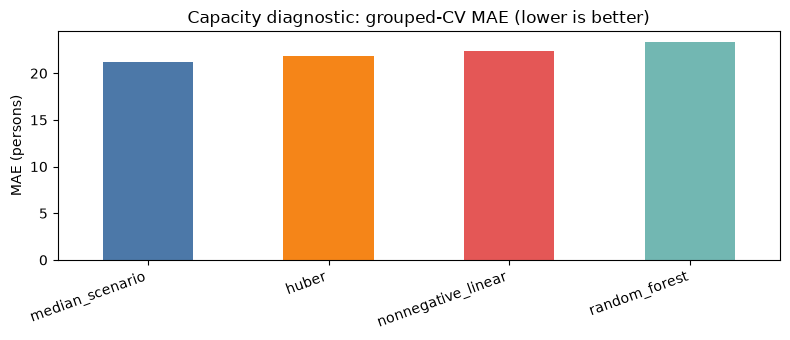

In [5]:
capacity_metrics = capacity_validation["metrics"]
capacity_rows = []
for model_name, values in capacity_metrics["models"].items():
    capacity_rows.append(
        {
            "모델": model_name,
            "MAE(명)": values["mae"],
            "RMSE(명)": values["rmse"],
            "중앙절대오차(명)": values["median_absolute_error"],
            "R²": values["r2"],
        }
    )
capacity_table = pd.DataFrame(capacity_rows).sort_values("MAE(명)")

assert capacity_validation["selected_model"] == "median_scenario"
assert capacity_validation["deployable"] is False
assert capacity_metrics["correlation"]["sufficient_positive_correlation"] is False
assert facility_audit["verified_operational_capacity_rows"] == 0

display(
    pd.DataFrame(
        [
            ("진단 표본", capacity_metrics["sample"]["valid_positive_rows"]),
            ("자치구 그룹", capacity_metrics["sample"]["borough_groups"]),
            ("면적-정원 Pearson", capacity_metrics["correlation"]["pearson"]),
            ("면적-정원 Spearman", capacity_metrics["correlation"]["spearman"]),
            ("필요 최소 Spearman", capacity_metrics["correlation"]["minimum_required_spearman"]),
            ("배치 승인", capacity_validation["deployable"]),
            ("기각 사유", capacity_validation["reason"]),
        ],
        columns=["항목", "값"],
    )
)
display(capacity_table)

ax = capacity_table.set_index("모델")["MAE(명)"].plot.bar(
    figsize=(8, 3.5), color=["#4c78a8", "#f58518", "#e45756", "#72b7b2"]
)
ax.set_title("Capacity diagnostic: grouped-CV MAE (lower is better)")
ax.set_ylabel("MAE (persons)")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 5. 핵심 수식과 독립 소형 예제 검증

현 구현의 범위에서 사용하는 식은 PDF와 같다.

\[
R_j=\frac{S_j}{\sum_i N_i w_{ij}},\qquad
A_i=\sum_jR_jw_{ij}
\]

\[
w(c)=\exp[-(c/\tau)^2]\mathbf{1}(c\le c_{\max}),\qquad
\Delta G_k=G(A_0)-G(A_k)
\]

아래 소형 예제는 저장 결과를 읽는 것이 아니라 구현 함수를 직접 호출한다. E2SFCA 공급 보존식 \(\sum_iN_iA_i=\sum_jS_j\)을 확인하고, 희소 국소갱신 exact Gini를 전체 배열을 다시 계산한 brute-force Gini와 비교한다.

In [6]:
from scipy import sparse

from elder_guardian.accessibility import e2sfca, weighted_gini
from elder_guardian.exact import ExactGiniEvaluator

small_population = np.array([100.0, 50.0, 25.0])
small_capacity = np.array([20.0, 10.0])
small_weights = sparse.csr_matrix(
    np.array(
        [
            [1.0, 0.2],
            [0.4, 1.0],
            [0.0, 0.5],
        ]
    )
)
small_access = e2sfca(small_population, small_capacity, small_weights)

evaluator = ExactGiniEvaluator(
    small_access.accessibility,
    small_population,
    baseline_reachable_supply=small_access.reachable_supply,
)
candidate_kernel = np.array([0.8, 0.4, 0.1])
candidate_capacity = 5.0
exact_small = evaluator.evaluate_candidate(
    np.arange(len(small_population)), candidate_kernel, candidate_capacity
)
candidate_denominator = float(np.dot(small_population, candidate_kernel))
candidate_increment = candidate_capacity * candidate_kernel / candidate_denominator
brute_gini_after = weighted_gini(
    small_access.accessibility + candidate_increment, small_population
)

assert small_access.conservation_error < 1e-12
assert exact_small.conservation_error < 1e-12
assert np.isclose(exact_small.gini_after, brute_gini_after, atol=1e-14)

display(
    pd.DataFrame(
        [
            ("E2SFCA reachable supply", small_access.reachable_supply),
            ("E2SFCA population-weighted access", small_access.supplied_access),
            ("E2SFCA conservation error", small_access.conservation_error),
            ("baseline weighted Gini", exact_small.gini_before),
            ("exact post-installation Gini", exact_small.gini_after),
            ("brute-force post-installation Gini", brute_gini_after),
            ("exact-vs-brute absolute error", abs(exact_small.gini_after - brute_gini_after)),
            ("candidate supply conservation error", exact_small.conservation_error),
        ],
        columns=["검증값", "결과"],
    )
)

,검증값,결과
0,E2SFCA reachable supply,30
1,E2SFCA population-weighted access,30
2,E2SFCA conservation error,0
3,baseline weighted Gini,0.095238095
4,exact post-installation Gini,0.11448482
5,brute-force post-installation Gini,0.11448482
6,exact-vs-brute absolute error,0
7,candidate supply conservation error,8.8817842e-16


## 6. exact 시나리오 성능

exact 계산기는 확률적 예측모델이 아니라 정해진 데이터와 가정에 대해 모든 후보의 목적함수를 계산하는 결정론적 평가기다. 따라서 “정확도 %” 대신 수식 일치, 공급 보존오차, 반복실행 일치, 처리시간을 본다.

,시나리오,Gini 전,Gini 후,ΔG,상대 Gini 감소(%),최상위 격자,유효 후보,전체 후보 처리(초),공급 보존오차
0,legal20_walk10_new20,0.3367702,0.33641913,0.00035107356,0.10424721,다사637437,52736,3.5987253,5.8207661e-11
1,legal20_walk15_new20,0.27622446,0.27587979,0.00034467158,0.12477953,다사639440,55973,4.8412722,1.4551915e-11
2,legal20_walk15_new40_BASE,0.27622446,0.27555215,0.00067231181,0.24339329,다사638441,55973,4.8063152,1.4551915e-11
3,legal20_walk15_new60,0.27622446,0.27526429,0.00096016957,0.34760483,다사640506,55973,4.8426843,1.4551915e-11
4,legal20_walk20_new40,0.24395744,0.24329519,0.00066225352,0.27146272,다사641507,57722,7.0385482,8.7311491e-11
5,historical_reference_walk15_new40,0.29278496,0.29228887,0.00049609865,0.1694413,다사642505,55973,4.7929235,1.4551915e-11
6,legal20_walk15_new40_1km_residual,0.27598118,0.27530955,0.00067162993,0.24336077,다사638441,56919,5.1046734,0


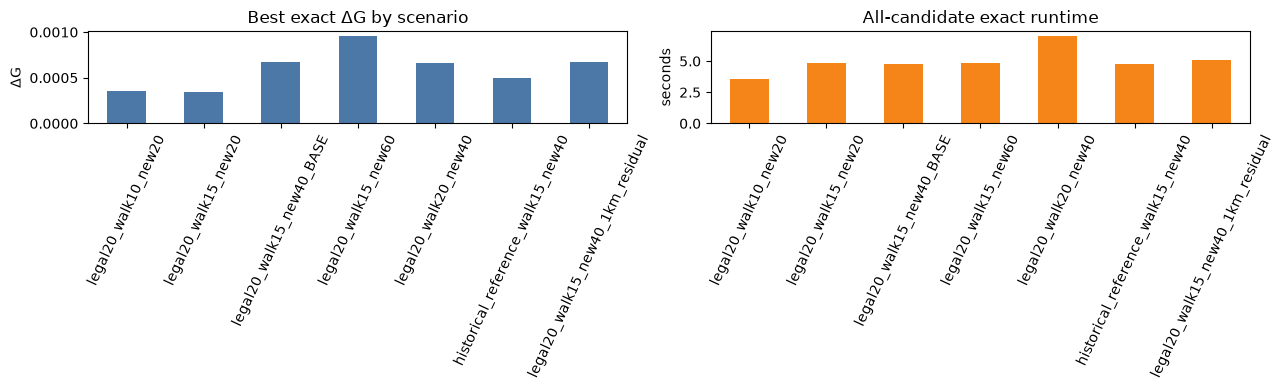

기본 시나리오는 **다사638441**에서 `Gini 0.276224463 → 0.275552151`이며, `ΔG=0.000672312` (상대 감소 **0.243%**)다. 효과가 0.24% 수준이므로 과도한 정책효과로 해석해서는 안 된다.

In [7]:
scenario_df = pd.DataFrame(scenario_summary)
scenario_df["relative_gini_reduction_pct"] = (
    100.0 * scenario_df["best_delta_gini"] / scenario_df["baseline_gini"]
)

assert np.allclose(
    scenario_df["baseline_gini"] - scenario_df["best_candidate_gini"],
    scenario_df["best_delta_gini"],
    rtol=0,
    atol=2e-15,
)
assert scenario_df["conservation_error"].max() < 1e-7
assert scenario_df["exact_runtime_seconds"].max() < 10

scenario_view = scenario_df[
    [
        "name",
        "baseline_gini",
        "best_candidate_gini",
        "best_delta_gini",
        "relative_gini_reduction_pct",
        "best_gid",
        "valid_candidates",
        "exact_runtime_seconds",
        "conservation_error",
    ]
].rename(
    columns={
        "name": "시나리오",
        "baseline_gini": "Gini 전",
        "best_candidate_gini": "Gini 후",
        "best_delta_gini": "ΔG",
        "relative_gini_reduction_pct": "상대 Gini 감소(%)",
        "best_gid": "최상위 격자",
        "valid_candidates": "유효 후보",
        "exact_runtime_seconds": "전체 후보 처리(초)",
        "conservation_error": "공급 보존오차",
    }
)
display(scenario_view)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
scenario_df.plot.bar(
    x="name", y="best_delta_gini", ax=axes[0], legend=False, color="#4c78a8"
)
axes[0].set_title("Best exact ΔG by scenario")
axes[0].set_xlabel("")
axes[0].set_ylabel("ΔG")
axes[0].tick_params(axis="x", rotation=65)
scenario_df.plot.bar(
    x="name", y="exact_runtime_seconds", ax=axes[1], legend=False, color="#f58518"
)
axes[1].set_title("All-candidate exact runtime")
axes[1].set_xlabel("")
axes[1].set_ylabel("seconds")
axes[1].tick_params(axis="x", rotation=65)
plt.tight_layout()
plt.show()

base = scenario_df.loc[scenario_df["name"] == "legal20_walk15_new40_BASE"].iloc[0]
display(
    Markdown(
        f"기본 시나리오는 **{base['best_gid']}**에서 "
        f"`Gini {base['baseline_gini']:.9f} → {base['best_candidate_gini']:.9f}`이며, "
        f"`ΔG={base['best_delta_gini']:.9f}` "
        f"(상대 감소 **{base['relative_gini_reduction_pct']:.3f}%**)다. "
        "효과가 0.24% 수준이므로 과도한 정책효과로 해석해서는 안 된다."
    )
)

### 6.1 기존시설 분모 0 별도 감사

저장된 `conservation_error`는 **도달 가능한 공급량**과 인구가중 접근성 합계만 비교하므로, 처음부터 도달 불가로 제외된 기존시설 공급은 잡지 못한다. PDF는 분모 0을 결측·연결·파라미터 오류로 분리해 남기라고 요구한다. 아래 셀은 각 시나리오의 기존시설 E2SFCA 분모를 원자료에서 다시 계산한다.

In [8]:
from elder_guardian.accessibility import gaussian_weight_matrix

sensitivity_values = pd.read_csv(
    ARTIFACTS / "population_1km_residual_sensitivity.csv"
)
sensitivity_population = population.copy()
sensitivity_population["population"] = sensitivity_population["gid"].map(
    sensitivity_values.set_index("gid")["population"]
)
assert sensitivity_population["population"].notna().all()
historical_facilities = pd.read_csv(
    ARTIFACTS / "facilities_historical_reference_winsorized.csv"
)

population_by_mode = {
    "PUBLISHED_LOWER_BOUND": population,
    "ONE_KM_RESIDUAL_SENSITIVITY": sensitivity_population,
}
facilities_by_mode = {
    "LEGAL_NOMINAL": facilities,
    "HISTORICAL_REFERENCE_WINSORIZED": historical_facilities,
}

denominator_audit_rows = []
zero_facility_rows = []
for scenario in manifest["config"]["scenarios"]:
    scenario_population = population_by_mode[scenario["population_mode"]]
    scenario_facilities = facilities_by_mode[scenario["existing_capacity_mode"]]
    weight_matrix = gaussian_weight_matrix(
        scenario_population[["x", "y"]].to_numpy(),
        scenario_facilities[["x", "y"]].to_numpy(),
        speed_m_per_min=manifest["config"]["walking_speed_m_per_min"],
        tau_minutes=scenario["tau_minutes"],
        cutoff_minutes=scenario["cutoff_minutes"],
    )
    denominator = np.asarray(
        weight_matrix.T @ scenario_population["population"].to_numpy()
    ).ravel()
    direct_baseline = e2sfca(
        scenario_population["population"].to_numpy(),
        scenario_facilities["model_capacity"].to_numpy(),
        weight_matrix,
    )
    direct_baseline_gini = weighted_gini(
        direct_baseline.accessibility,
        scenario_population["population"].to_numpy(),
    )
    stored_baseline_gini = next(
        item["baseline_gini"]
        for item in scenario_summary
        if item["name"] == scenario["name"]
    )
    zero_mask = denominator <= 0
    total_supply = float(scenario_facilities["model_capacity"].sum())
    omitted_supply = float(
        scenario_facilities.loc[zero_mask, "model_capacity"].sum()
    )
    denominator_audit_rows.append(
        {
            "시나리오": scenario["name"],
            "기존시설": len(scenario_facilities),
            "분모0 시설": int(zero_mask.sum()),
            "총공급": total_supply,
            "도달공급": total_supply - omitted_supply,
            "조용히 제외된 공급": omitted_supply,
            "재계산 Gini": direct_baseline_gini,
            "저장 Gini 절대차": abs(direct_baseline_gini - stored_baseline_gini),
            "판정": "통과" if not zero_mask.any() else "오류 플래그 필요",
        }
    )
    if zero_mask.any():
        details = scenario_facilities.loc[
            zero_mask,
            ["source_record_id", "facility_name", "borough", "model_capacity"],
        ].copy()
        details.insert(0, "scenario", scenario["name"])
        zero_facility_rows.append(details)

denominator_audit = pd.DataFrame(denominator_audit_rows)
display(denominator_audit)
if zero_facility_rows:
    display(Markdown("**분모 0 기존시설 상세**"))
    display(pd.concat(zero_facility_rows, ignore_index=True))

assert denominator_audit.loc[
    denominator_audit["시나리오"] == "legal20_walk10_new20", "분모0 시설"
].iloc[0] == 1
assert denominator_audit.loc[
    denominator_audit["시나리오"] == "legal20_walk15_new40_BASE", "분모0 시설"
].iloc[0] == 0
assert denominator_audit["저장 Gini 절대차"].max() < 5e-15

display(
    Markdown(
        "**판정:** 기본 시나리오는 기존시설 분모 0이 없어 정상이다. "
        "`legal20_walk10_new20`은 흐능날 경로당 정원 20명이 도달공급에서 빠졌는데 "
        "기존 gate가 이를 검출하지 못했다. 이 민감도 시나리오는 오류상태로 표시하고 "
        "연결성/인구 억제/10분 cutoff 원인을 확인한 뒤 재실행해야 한다."
    )
)

,시나리오,기존시설,분모0 시설,총공급,도달공급,조용히 제외된 공급,재계산 Gini,저장 Gini 절대차,판정
0,legal20_walk10_new20,3644,1,"72,800","72,780",20,0.3367702,1.110223e-16,오류 플래그 필요
1,legal20_walk15_new20,3644,0,"72,800","72,800",0,0.27622446,2.8310687e-15,통과
2,legal20_walk15_new40_BASE,3644,0,"72,800","72,800",0,0.27622446,2.8310687e-15,통과
3,legal20_walk15_new60,3644,0,"72,800","72,800",0,0.27622446,2.8310687e-15,통과
4,legal20_walk20_new40,3644,0,"72,800","72,800",0,0.24395744,3.3306691e-15,통과
5,historical_reference_walk15_new40,3644,0,"101,585.36","101,585.36",0,0.29278496,9.9920072e-16,통과
6,legal20_walk15_new40_1km_residual,3644,0,"72,800","72,800",0,0.27598118,1.8873791e-15,통과


**분모 0 기존시설 상세**

,scenario,source_record_id,facility_name,borough,model_capacity
0,legal20_walk10_new20,seoul-senior-center:2025-06:3134,흐능날 경로당,서초구,20


**판정:** 기본 시나리오는 기존시설 분모 0이 없어 정상이다. `legal20_walk10_new20`은 흐능날 경로당 정원 20명이 도달공급에서 빠졌는데 기존 gate가 이를 검출하지 못했다. 이 민감도 시나리오는 오류상태로 표시하고 연결성/인구 억제/10분 cutoff 원인을 확인한 뒤 재실행해야 한다.

## 7. 전체 후보 반복실행 재현성

서로 다른 두 실행 디렉터리에서 7개 시나리오×후보 결과의 키, 유효성, Gini를 직접 비교한다. 런타임 열은 장비 부하에 따라 달라질 수 있으므로 수치결과 비교에서 제외한다.

In [9]:
reference_exact = pd.read_csv(
    REFERENCE_RUN / "exact_candidate_results.csv", usecols=exact_columns
)
left = exact_results.sort_values(["scenario", "gid"]).reset_index(drop=True)
right = reference_exact.sort_values(["scenario", "gid"]).reset_index(drop=True)

keys_equal = left[["scenario", "gid"]].equals(right[["scenario", "gid"]])
valid_equal = left["valid"].equals(right["valid"])
max_candidate_gini_diff = float(
    np.nanmax(np.abs(left["candidate_gini"] - right["candidate_gini"]))
)
max_delta_gini_diff = float(
    np.nanmax(np.abs(left["delta_gini"] - right["delta_gini"]))
)

assert len(left) == len(right) == 404_054
assert keys_equal and valid_equal
assert max_candidate_gini_diff == 0.0
assert max_delta_gini_diff == 0.0

display(
    pd.DataFrame(
        [
            ("비교 행", len(left)),
            ("시나리오·격자 키 일치", keys_equal),
            ("유효성 플래그 일치", valid_equal),
            ("candidate_gini 최대 차이", max_candidate_gini_diff),
            ("delta_gini 최대 차이", max_delta_gini_diff),
        ],
        columns=["검증", "결과"],
    )
)

,검증,결과
0,비교 행,404054
1,시나리오·격자 키 일치,True
2,유효성 플래그 일치,True
3,candidate_gini 최대 차이,0
4,delta_gini 최대 차이,0


In [10]:
valid_mask = exact_results["valid"].astype(bool)
invalid_mask = ~valid_mask
identity_error = float(
    np.nanmax(
        np.abs(
            (
                exact_results.loc[valid_mask, "candidate_gini"]
                + exact_results.loc[valid_mask, "delta_gini"]
            ).to_numpy()
            - exact_results.loc[valid_mask, "scenario"].map(
                scenario_df.set_index("name")["baseline_gini"]
            ).to_numpy()
        )
    )
)
exact_diagnostics = pd.DataFrame(
    [
        ("전체 행", len(exact_results)),
        ("중복 (scenario, gid)", int(exact_results.duplicated(["scenario", "gid"]).sum())),
        ("유효 후보행", int(valid_mask.sum())),
        ("분모0 무효 후보행", int(invalid_mask.sum())),
        ("무효행 Gini/ΔG 모두 NaN", bool(exact_results.loc[invalid_mask, ["candidate_gini", "delta_gini"]].isna().all().all())),
        ("음수 ΔG 행(불평등 악화, 클리핑 안 함)", int((exact_results.loc[valid_mask, "delta_gini"] < 0).sum())),
        ("G_before-G_after=ΔG 최대오차", identity_error),
    ],
    columns=["exact 감사", "결과"],
)
assert exact_results.duplicated(["scenario", "gid"]).sum() == 0
assert invalid_mask.sum() == 12_785
assert exact_results.loc[invalid_mask, ["candidate_gini", "delta_gini"]].isna().all().all()
assert identity_error < 2e-15
display(exact_diagnostics)

,exact 감사,결과
0,전체 행,404054
1,"중복 (scenario, gid)",0
2,유효 후보행,391269
3,분모0 무효 후보행,12785
4,무효행 Gini/ΔG 모두 NaN,True
5,"음수 ΔG 행(불평등 악화, 클리핑 안 함)",216677
6,G_before-G_after=ΔG 최대오차,1.6653345e-16


## 8. 후보 결과와 설치 가능성 경고

기본 시나리오의 exact 1위와 7개 시나리오를 종합한 강건 1위는 서로 다르다. 더 중요하게, 후보는 **필지**가 아니라 **100m 격자 중심점**이다. 후속 point-level 프로토타입에서 기본 1위 중심점은 공식 도시계획 도로 폴리곤 내부로 확인되어 그 점 자체는 제외 대상이다. 셀 전체를 폐기하거나 실제 부지로 확정할 근거는 아니며, 연속지적도 기반 필지 열거가 필요하다.

### 기본 시나리오 exact 상위 5개

,gid,borough,latitude,longitude,baseline_gini,candidate_gini,delta_gini
0,다사638441,강남구,37.4959,127.09104,0.27622446,0.27555215,0.00067231181
1,다사639441,강남구,37.495904,127.09217,0.27622446,0.27555394,0.00067052626
2,다사637441,강남구,37.495896,127.08991,0.27622446,0.27555777,0.0006666941
3,다사637442,강남구,37.496798,127.0899,0.27622446,0.27555805,0.00066641347
4,다사638442,강남구,37.496801,127.09104,0.27622446,0.27555916,0.00066530611


### 7개 시나리오 강건 상위 5개

,gid,borough,latitude,longitude,mean_percentile,worst_percentile,mean_delta_gini
0,다사635507,광진구,37.555377,127.08732,0.99964714,0.99927943,0.00058718583
1,다사641506,광진구,37.554499,127.09412,0.99960857,0.99846405,0.00058718986
2,다사642506,광진구,37.554503,127.09525,0.99960239,0.99886226,0.00058621511
3,다사641505,광진구,37.553598,127.09412,0.99957942,0.99865367,0.00058681275
4,다사642505,광진구,37.553601,127.09525,0.99957587,0.99896053,0.00058613612


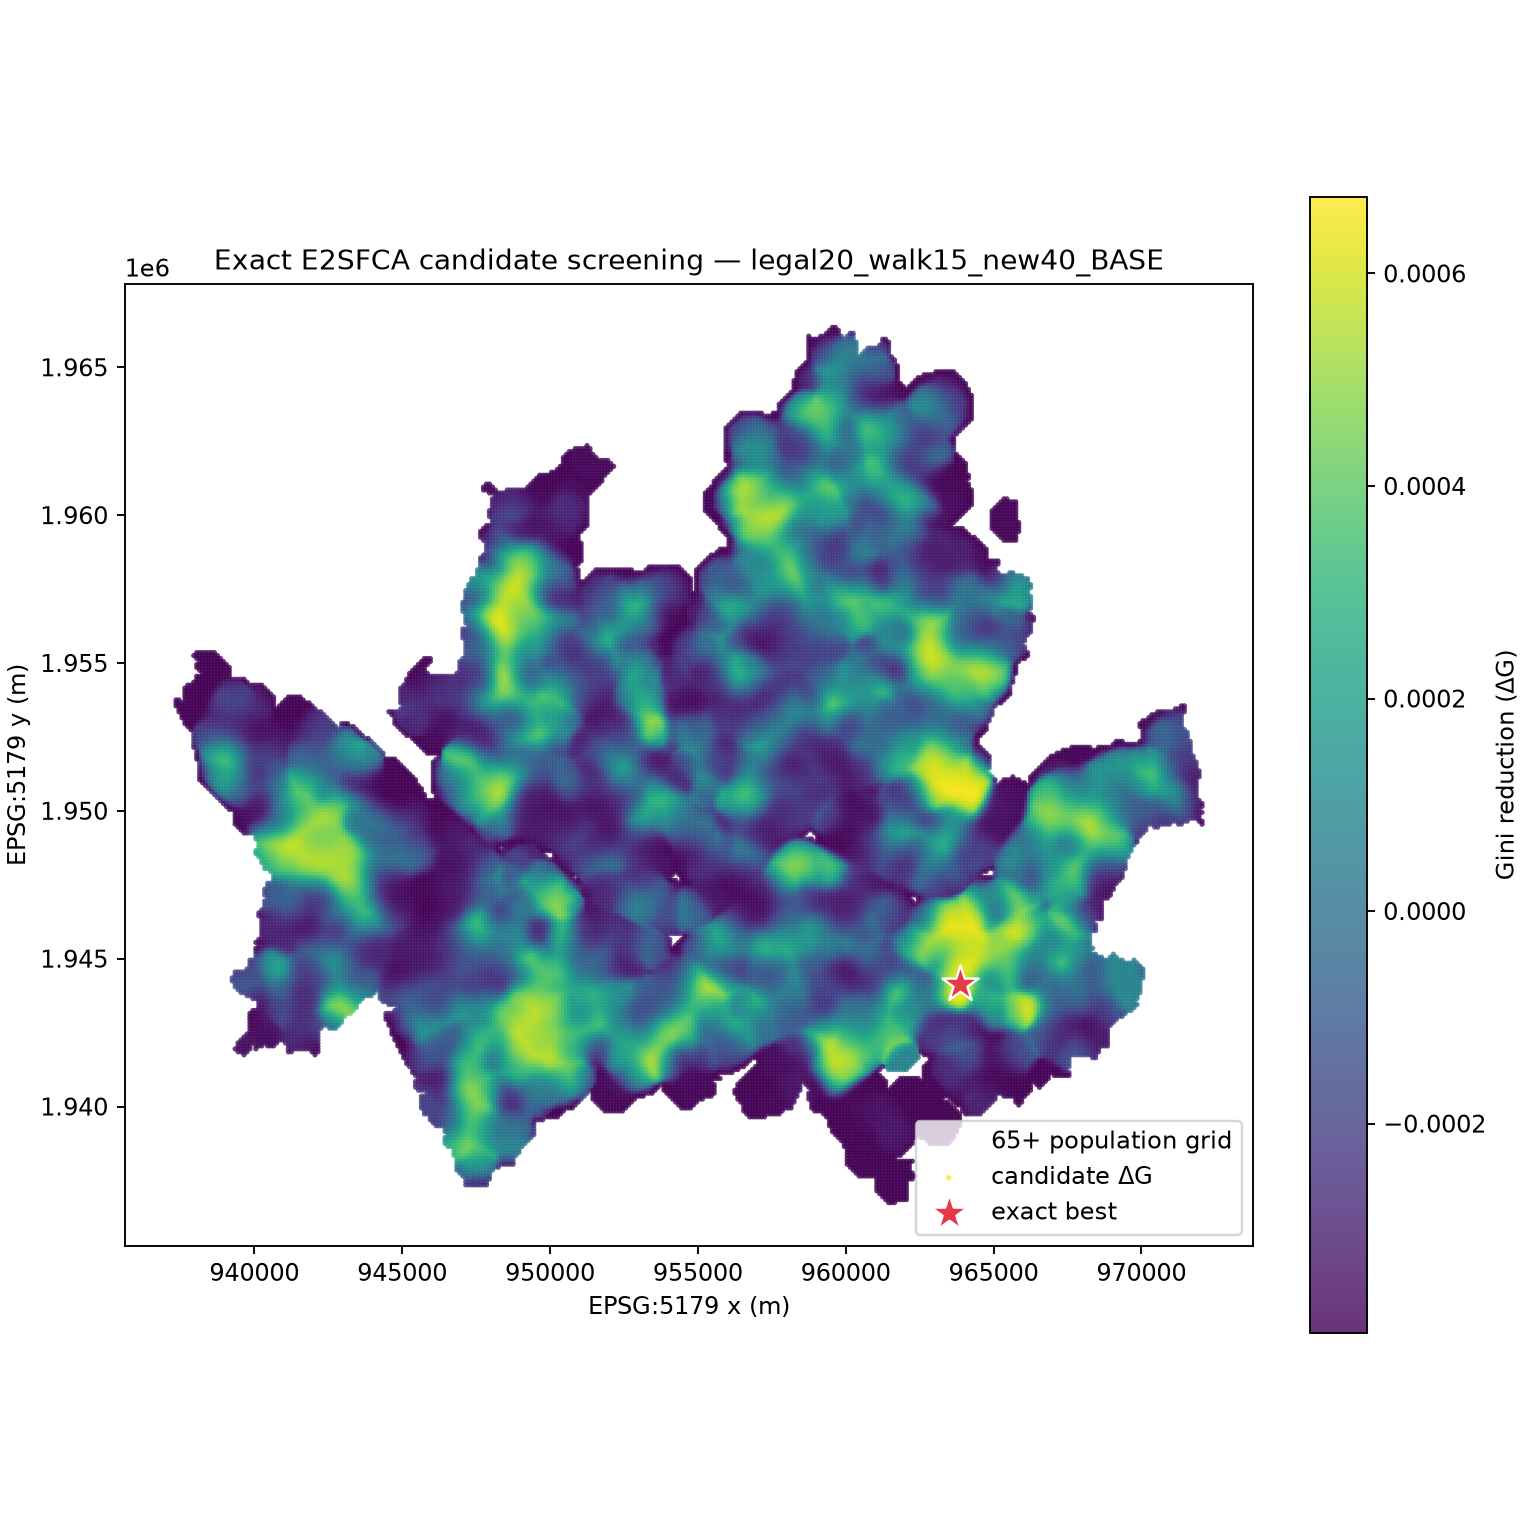

,격자,자치구/동,point-level 판정,강한 제외 증거,검토 증거
0,다사638441,강남구 일원1동,EXCLUDE_EXACT_POINT_KEEP_CELL_FOR_PARCEL_SEARCH,"서울시 도시계획시설 도로 폴리곤 내부 / 서울시 2025 비오톱에서 도로로 분류 / OSM 주요도로 중심선의 보수적 반폭 이내 (primary, 8.0m)",용도지역은 적법성 판정이 아니라 후속 법규검토 신호: 자연녹지지역
1,다사635507,광진구 중곡2동,MANUAL_REVIEW_AND_PARCEL_SEARCH,없음,OSM 기존 건물 내부: 철거·매입·전환 가능성 때문에 100m 셀 전체를 자동 제외하면 안 됨 / 용도지역은 적법성 판정이 아니라 후속 법규검토 신호: 제2종일반주거지역


In [11]:
base_top = pd.read_csv(ARTIFACTS / "recommendations_base_top20.csv")
robust_top = pd.read_csv(ARTIFACTS / "recommendations_robust_top20.csv")

display(Markdown("### 기본 시나리오 exact 상위 5개"))
display(
    base_top[
        ["gid", "borough", "latitude", "longitude", "baseline_gini", "candidate_gini", "delta_gini"]
    ].head(5)
)
display(Markdown("### 7개 시나리오 강건 상위 5개"))
display(
    robust_top[
        ["gid", "borough", "latitude", "longitude", "mean_percentile", "worst_percentile", "mean_delta_gini"]
    ].head(5)
)

display(Image(filename=str(ARTIFACTS / "map_base_exact.png"), width=900))

feasibility_path = ROOT / "tmp" / "feasibility_research" / "candidate_feasibility_snapshot.json"
if feasibility_path.exists():
    with feasibility_path.open(encoding="utf-8") as handle:
        feasibility = json.load(handle)
    feasibility_rows = []
    for item in feasibility["candidate_results"]:
        assessment = item["assessment"]
        feasibility_rows.append(
            {
                "격자": item["candidate_id"],
                "자치구/동": f"{item['borough']} {item['neighbourhood']}",
                "point-level 판정": assessment["disposition"],
                "강한 제외 증거": " / ".join(assessment["hard_exclusion_evidence"]) or "없음",
                "검토 증거": " / ".join(assessment["review_evidence"]) or "없음",
            }
        )
    display(pd.DataFrame(feasibility_rows))
else:
    display(Markdown("후속 point-level 설치가능성 스냅샷이 없어 이 단계는 재실행하지 않았다."))

## 9. 대리모델의 실제 성능과 승인 게이트

저장 성능표는 일반 무작위 분할이 아니라 5-fold 자치구 GroupKFold의 OOF 예측을 사용한다. 다만 metric 함수가 이를 다시 **25개 자치구×7개 시나리오=175개 자치구 내부 단위**로 쪼개 평가한다. PDF의 정책 목적은 서울 전체 후보집합에서 한 곳을 고르는 것이므로, 이 175단위 수치는 “자치구 내부 진단”이지 서울 전체 정책 성능이 아니다. 다음 절에서 서울 전체 지표를 별도로 재계산한다.

- `MAE`: ΔG 수치 오차
- `Spearman`: 후보 순위 상관
- `Recall@20`: 실제 상위 후보가 예측 상위 20에 얼마나 포함되는지
- `RecallBest@20`: 각 평가단위의 실제 1위가 예측 상위 20 안에 들어오는 비율
- `relative regret@20`: 예측 shortlist 안에서 exact 재평가했을 때 실제 최상 대비 놓친 효과의 비율

승인은 네 기준을 모두 만족해야 한다. 특히 실제 1위를 놓치지 않기 위한 `RecallBest@20 ≥ 0.95`가 병목이다. 또한 PDF의 pairwise 순위손실과 대중교통 그래프 edge는 구현되지 않았고, 현재 학습손실은 top-emphasized Huber 회귀다.

,모델,MAE,Spearman,Recall@20,RecallBest@20,평균 상대후회@20,상대후회 p95@20,평가단위,학습시간(초),승인
0,SpatialGCN,2.8424255e-05,0.98284046,0.66742857,0.78857143,0.0039452741,0.032454859,175,219.24512,False
1,HistGradientBoosting,9.3703253e-05,0.97568412,0.434,0.52571429,0.012889591,0.070144105,175,2.249289,False
2,NodeMLP,2.5723729e-05,0.98429659,0.72314286,0.89142857,0.00091126897,0.0030167128,175,427.84429,False
3,FixedGCNMLPEnsemble,2.4768595e-05,0.98560773,0.72742857,0.87428571,0.0011561532,0.0032047501,175,427.84429,False


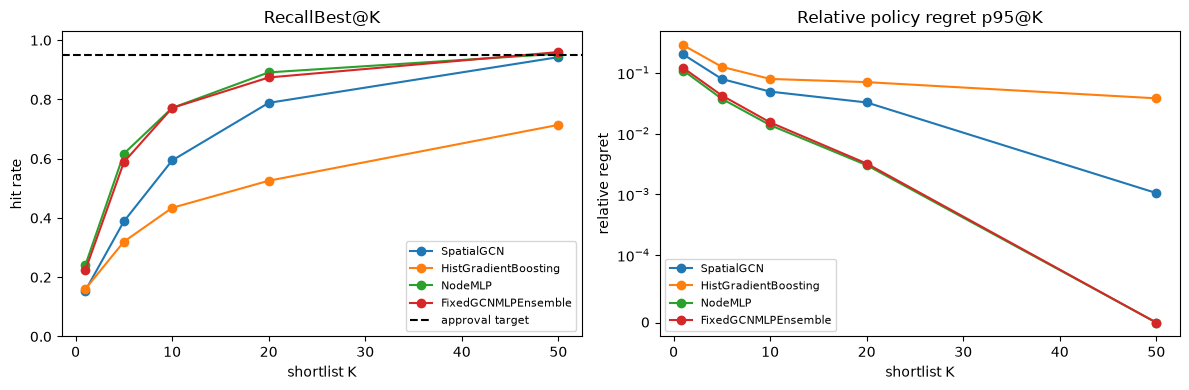

In [12]:
with (ARTIFACTS / "surrogate_metrics.json").open(encoding="utf-8") as handle:
    original_surrogate_metrics = json.load(handle)
with (ARTIFACTS / "surrogate_improvement.json").open(encoding="utf-8") as handle:
    surrogate_improvement = json.load(handle)
with (ARTIFACTS / "surrogate_ranking_curves.json").open(encoding="utf-8") as handle:
    original_curves = json.load(handle)

thresholds = gates["thresholds"]
all_surrogate_metrics = original_surrogate_metrics + surrogate_improvement["metrics"]
surrogate_table = pd.DataFrame(all_surrogate_metrics)
surrogate_table["gate_pass"] = (
    (surrogate_table["spearman"] >= thresholds["min_spearman"])
    & (surrogate_table["recall_at_k"] >= thresholds["min_recall_at_20"])
    & (surrogate_table["best_in_predicted_top_k"] >= thresholds["min_recall_best_at_20"])
    & (surrogate_table["relative_policy_regret"] <= thresholds["max_relative_policy_regret_at_20"])
)

assert not surrogate_table["gate_pass"].any()
assert gates["gcn_approved"] is False

display(
    surrogate_table[
        [
            "model",
            "mae",
            "spearman",
            "recall_at_k",
            "best_in_predicted_top_k",
            "relative_policy_regret",
            "relative_policy_regret_p95",
            "evaluation_units",
            "fit_seconds",
            "gate_pass",
        ]
    ].rename(
        columns={
            "model": "모델",
            "mae": "MAE",
            "spearman": "Spearman",
            "recall_at_k": "Recall@20",
            "best_in_predicted_top_k": "RecallBest@20",
            "relative_policy_regret": "평균 상대후회@20",
            "relative_policy_regret_p95": "상대후회 p95@20",
            "evaluation_units": "평가단위",
            "fit_seconds": "학습시간(초)",
            "gate_pass": "승인",
        }
    )
)

all_curves = {
    **original_curves,
    **surrogate_improvement["ranking_curves"],
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name, curve in all_curves.items():
    ks = sorted(int(k) for k in curve)
    axes[0].plot(
        ks,
        [curve[str(k)]["best_in_predicted_top_k"] for k in ks],
        marker="o",
        label=model_name,
    )
    axes[1].plot(
        ks,
        [curve[str(k)]["relative_policy_regret_p95"] for k in ks],
        marker="o",
        label=model_name,
    )
axes[0].axhline(thresholds["min_recall_best_at_20"], color="black", linestyle="--", label="approval target")
axes[0].set_title("RecallBest@K")
axes[0].set_xlabel("shortlist K")
axes[0].set_ylabel("hit rate")
axes[0].set_ylim(0, 1.03)
axes[1].set_title("Relative policy regret p95@K")
axes[1].set_xlabel("shortlist K")
axes[1].set_ylabel("relative regret")
axes[1].set_yscale("symlog", linthresh=1e-4)
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 9.1 SpatialGCN 전체 모델 계약

GNN은 최종 정책모델이 아니라 exact \(\Delta G\)를 근사하는 후보 압축기다. 후보를 노드로 보고 같은 자치구 안의 145m 이내 물리 인접 후보를 연결한다.

\[
\hat A=D^{-1/2}(A+I)D^{-1/2}
\]

\[
H_1=\operatorname{ReLU}(W_1\hat AX+b_1),\quad
H_2=\operatorname{ReLU}(W_2\hat AH_1+b_2),\quad
\widehat{\Delta G}=W_oH_2+b_o
\]

두 번의 graph propagation 뒤 선형 회귀값을 출력한다. 버스·지하철·환승 edge는 없으며, 저장 checkpoint의 `capacity_and_travel_semantics`도 실제 관측성과가 아니라 시나리오 입력임을 명시한다.

In [13]:
import torch
from scipy.sparse.csgraph import connected_components

from elder_guardian.surrogate import SpatialGCN, normalized_spatial_adjacency

gnn_bundle = torch.load(
    ARTIFACTS / "gnn_surrogate.pt", map_location="cpu", weights_only=True
)
gnn_tensor_card = np.load(
    ARTIFACTS / "surrogate_training_tensor.npz", allow_pickle=False
)
gnn_deployment_contract = json.loads(
    (ARTIFACTS / "gnn_deployment_contract.json").read_text(encoding="utf-8")
)
gnn_model_card = SpatialGCN(
    gnn_bundle["input_dim"],
    gnn_bundle["hidden_dim"],
    gnn_bundle["dropout"],
)
gnn_model_card.load_state_dict(gnn_bundle["state_dict"], strict=True)
graph_card = normalized_spatial_adjacency(
    gnn_tensor_card["xy"], gnn_tensor_card["groups"]
)
component_count, component_labels = connected_components(
    graph_card, directed=False
)
structural_degree = np.asarray((graph_card != 0).sum(axis=1)).ravel()

model_contract = pd.DataFrame(
    [
        ("목적", "exact ΔG 근사 후 shortlist 생성"),
        ("후보 노드", graph_card.shape[0]),
        ("시나리오", len(gnn_tensor_card["scenario_names"])),
        ("입력 shape", str(gnn_tensor_card["features"].shape)),
        ("출력 shape", str(gnn_tensor_card["targets"].shape)),
        ("입력 특성", gnn_bundle["input_dim"]),
        ("hidden", gnn_bundle["hidden_dim"]),
        ("dropout", gnn_bundle["dropout"]),
        ("학습 파라미터", sum(parameter.numel() for parameter in gnn_model_card.parameters())),
        ("checkpoint bytes", (ARTIFACTS / "gnn_surrogate.pt").stat().st_size),
        ("artifact type/version", f"{gnn_deployment_contract['artifact_type']} / {gnn_deployment_contract['model_version']}"),
        ("sparse nnz(self-loop 포함)", graph_card.nnz),
        ("무방향 non-self edge", int((graph_card.nnz - graph_card.shape[0]) / 2)),
        ("연결성분", component_count),
        ("self-loop만 있는 노드", int((structural_degree == 1).sum())),
        ("degree 중앙값/최댓값", f"{np.median(structural_degree):.0f} / {structural_degree.max():.0f}"),
        ("target 의미", gnn_bundle["capacity_and_travel_semantics"]),
        ("최종 권한", gates["final_authority"]),
    ],
    columns=["GNN 계약", "값"],
)
display(model_contract)

training_contract = pd.DataFrame(
    [
        ("분할", "자치구 GroupKFold 5개"),
        ("fold 내부 validation", "train 자치구 중 1개, early stopping"),
        ("loss", "top-emphasized Huber (pairwise ranking loss 없음)"),
        ("optimizer", "Adam"),
        ("learning rate", manifest["config"]["surrogate"]["learning_rate"]),
        ("weight decay", manifest["config"]["surrogate"]["weight_decay"]),
        ("epoch / patience", f"{manifest['config']['surrogate']['epochs']} / {manifest['config']['surrogate']['patience']}"),
        ("top loss weight", manifest["config"]["surrogate"]["top_loss_weight"]),
        ("seed", manifest["config"]["random_seed"]),
        ("전처리", "feature/target scaler를 fold train 노드에서만 적합"),
        ("저장 checkpoint", "전체 라벨 160 epoch 고정 재학습; OOF fold best-state 아님"),
        ("최종모델 early stopping/loss log", "없음"),
        ("checkpoint에 빠진 학습계약", "lr, weight decay, top weight, epochs, adjacency radius"),
        ("외부 시점·도시 검증", "없음"),
        ("미사용 시나리오 holdout", "없음"),
        ("여러 seed 안정성", "없음"),
    ],
    columns=["학습·검증 항목", "설정/상태"],
)
display(training_contract)

feature_groups = {
    "수요": [
        "log_population",
        "log_local_population_500m",
        "log_local_population_1000m",
        "log_local_population_2000m",
    ],
    "기존 접근성·공급": [
        "log_baseline_accessibility",
        "log_local_supply_500m",
        "log_local_supply_1000m",
        "log_local_supply_2000m",
        "log_nearest_facility_distance",
        "log_demand_supply_ratio_1000m",
    ],
    "후보 catchment": [
        "log_candidate_weighted_demand",
        "log_candidate_baseline_access_mean",
        "log_candidate_baseline_access_std",
        "candidate_low_access_share",
        "log_candidate_low_access_gap",
    ],
    "시나리오": [
        "new_capacity",
        "tau_minutes",
        "cutoff_minutes",
        "historical_reference_mode",
    ],
}
feature_rows = [
    {"구분": category, "특성": feature}
    for category, feature_names in feature_groups.items()
    for feature in feature_names
]
feature_table = pd.DataFrame(feature_rows)
assert feature_table["특성"].tolist() == list(gnn_bundle["feature_names"])
assert gnn_tensor_card["features"].shape == (7, 52_736, 19)
assert sum(parameter.numel() for parameter in gnn_model_card.parameters()) == 1_729
assert gnn_deployment_contract["checkpoint"]["sha256"] == sha256_file(
    ARTIFACTS / "gnn_surrogate.pt"
)
assert gnn_deployment_contract["required_tensor"]["sha256"] == sha256_file(
    ARTIFACTS / "surrogate_training_tensor.npz"
)
assert gnn_deployment_contract["status"] == "NOT_APPROVED_FOR_SHORTLIST_AT_K20"
display(feature_table)

,GNN 계약,값
0,목적,exact ΔG 근사 후 shortlist 생성
1,후보 노드,52736
2,시나리오,7
3,입력 shape,"(7, 52736, 19)"
4,출력 shape,"(7, 52736)"
5,입력 특성,19
6,hidden,32
7,dropout,0.15
8,학습 파라미터,1729
9,checkpoint bytes,11549


,학습·검증 항목,설정/상태
0,분할,자치구 GroupKFold 5개
1,fold 내부 validation,"train 자치구 중 1개, early stopping"
2,loss,top-emphasized Huber (pairwise ranking loss 없음)
3,optimizer,Adam
4,learning rate,0.01
5,weight decay,0.0001
6,epoch / patience,160 / 20
7,top loss weight,20
8,seed,20260727
9,전처리,feature/target scaler를 fold train 노드에서만 적합


,구분,특성
0,수요,log_population
1,수요,log_local_population_500m
2,수요,log_local_population_1000m
3,수요,log_local_population_2000m
4,기존 접근성·공급,log_baseline_accessibility
5,기존 접근성·공급,log_local_supply_500m
6,기존 접근성·공급,log_local_supply_1000m
7,기존 접근성·공급,log_local_supply_2000m
8,기존 접근성·공급,log_nearest_facility_distance
9,기존 접근성·공급,log_demand_supply_ratio_1000m


## 10. 저장 OOF 예측으로 순위지표 재계산

JSON에 적힌 성능표를 그대로 믿지 않고, 저장된 out-of-fold 예측 배열과 정답을 다시 읽어 동일한 평가 함수를 호출한다. 아래 최대 차이는 재계산값과 저장된 ranking curve 사이의 차이다.

In [14]:
from elder_guardian.surrogate import ranking_curve

training_tensor = np.load(ARTIFACTS / "surrogate_training_tensor.npz", allow_pickle=False)
original_oof = np.load(ARTIFACTS / "surrogate_oof_predictions.npz", allow_pickle=False)
improved_oof = np.load(ARTIFACTS / "surrogate_improvement_oof.npz", allow_pickle=False)

truth = training_tensor["targets"]
groups = training_tensor["groups"]
xy = training_tensor["xy"]
assert np.array_equal(truth, original_oof["truth"])
assert np.array_equal(truth, improved_oof["truth"])

oof_specs = [
    ("SpatialGCN", original_oof["gcn"], original_curves["SpatialGCN"]["20"]),
    (
        "HistGradientBoosting",
        original_oof["hist_gradient_boosting"],
        original_curves["HistGradientBoosting"]["20"],
    ),
    ("NodeMLP", improved_oof["mlp"], surrogate_improvement["ranking_curves"]["NodeMLP"]["20"]),
    (
        "FixedGCNMLPEnsemble",
        improved_oof["fixed_ensemble"],
        surrogate_improvement["ranking_curves"]["FixedGCNMLPEnsemble"]["20"],
    ),
]
metric_fields = [
    "mae",
    "spearman",
    "recall_at_k",
    "best_in_predicted_top_k",
    "policy_regret",
    "relative_policy_regret",
    "relative_policy_regret_p95",
]
recheck_rows = []
for model_name, prediction, saved in oof_specs:
    assert np.isfinite(prediction).all()
    recalculated = ranking_curve(
        truth,
        prediction,
        groups,
        top_k_values=(20,),
        random_seed=manifest["config"]["random_seed"],
    )["20"]
    max_difference = max(abs(recalculated[field] - saved[field]) for field in metric_fields)
    recheck_rows.append(
        {
            "모델": model_name,
            "예측 배열 shape": str(prediction.shape),
            "유한값": bool(np.isfinite(prediction).all()),
            "저장지표 대비 최대차이": max_difference,
        }
    )
    assert max_difference < 1e-12

display(pd.DataFrame(recheck_rows))

,모델,예측 배열 shape,유한값,저장지표 대비 최대차이
0,SpatialGCN,"(7, 52736)",True,0
1,HistGradientBoosting,"(7, 52736)",True,0
2,NodeMLP,"(7, 52736)",True,0
3,FixedGCNMLPEnsemble,"(7, 52736)",True,0


### 10.1 정책 모집단과 공간 버퍼 재감사

같은 OOF 예측을 서울 전체 후보집합으로 묶어 `Recall@20`과 `RecallBest@20`을 다시 계산한다. 또한 5-fold GroupKFold의 각 test 격자에서 가장 가까운 train 격자까지의 거리를 측정한다. 자치구가 fold 사이에서 겹치지는 않지만 경계 양쪽 격자는 100m까지 붙어 있어 연속 공간 블록/버퍼 검증과 같지 않다.

In [15]:
from scipy.spatial import cKDTree
from sklearn.model_selection import GroupKFold

seoul_group = np.repeat("서울전체", len(groups))
fold_labels = np.empty(len(groups), dtype=object)
buffer_rows = []
splitter = GroupKFold(n_splits=manifest["config"]["surrogate"]["folds"])
for fold_index, (train_index, test_index) in enumerate(
    splitter.split(xy, groups=groups), start=1
):
    fold_labels[test_index] = f"fold-{fold_index}"
    nearest_distance = cKDTree(xy[train_index]).query(xy[test_index], k=1)[0]
    buffer_rows.append(
        {
            "fold": fold_index,
            "test 격자": len(test_index),
            "train까지 최소거리(m)": float(nearest_distance.min()),
            "150m 이내(%)": 100.0 * float(np.mean(nearest_distance <= 150.0)),
            "765m 이내(%)": 100.0 * float(np.mean(nearest_distance <= 765.0)),
        }
    )

policy_metric_rows = []
for model_name, prediction, _ in oof_specs:
    district_metric = ranking_curve(
        truth, prediction, groups, top_k_values=(20,)
    )["20"]
    fold_metric = ranking_curve(
        truth, prediction, fold_labels, top_k_values=(20,)
    )["20"]
    seoul_metric = ranking_curve(
        truth, prediction, seoul_group, top_k_values=(20,)
    )["20"]
    policy_metric_rows.append(
        {
            "모델": model_name,
            "자치구 Recall@20": district_metric["recall_at_k"],
            "자치구 RecallBest@20": district_metric["best_in_predicted_top_k"],
            "외부fold RecallBest@20": fold_metric["best_in_predicted_top_k"],
            "서울전체 Recall@20": seoul_metric["recall_at_k"],
            "서울전체 RecallBest@20": seoul_metric["best_in_predicted_top_k"],
            "서울전체 평가단위": seoul_metric["evaluation_units"],
        }
    )

policy_metrics = pd.DataFrame(policy_metric_rows)
buffer_audit = pd.DataFrame(buffer_rows)
display(Markdown("**같은 OOF 예측, 서로 다른 정책 모집단**"))
display(policy_metrics)
display(Markdown("**train–test 공간거리 감사**"))
display(buffer_audit)

assert policy_metrics["서울전체 평가단위"].eq(7).all()
assert buffer_audit["train까지 최소거리(m)"].min() <= 100.000001
assert policy_metrics["서울전체 RecallBest@20"].max() < 0.95

**같은 OOF 예측, 서로 다른 정책 모집단**

,모델,자치구 Recall@20,자치구 RecallBest@20,외부fold RecallBest@20,서울전체 Recall@20,서울전체 RecallBest@20,서울전체 평가단위
0,SpatialGCN,0.66742857,0.78857143,0.71428571,0.42142857,0.57142857,7
1,HistGradientBoosting,0.434,0.52571429,0.057142857,0,0,7
2,NodeMLP,0.72314286,0.89142857,0.77142857,0.47857143,0.85714286,7
3,FixedGCNMLPEnsemble,0.72742857,0.87428571,0.85714286,0.52857143,0.71428571,7


**train–test 공간거리 감사**

,fold,test 격자,train까지 최소거리(m),150m 이내(%),765m 이내(%)
0,1,10440,100,10.009579,51.64751
1,2,10714,100,9.8095949,50.046668
2,3,10545,100,8.9805595,46.28734
3,4,10536,100,7.4316629,38.297267
4,5,10501,100,8.3230169,43.072088


### 10.2 SpatialGCN의 실제 정책성능

높은 MAE·상관 성능이 “실제 최적 후보를 놓치지 않는다”는 뜻은 아니다. 아래에서는 서울 전체 52,736개 후보 중 실제 1위의 GCN 예측순위, top-20 exact 재평가 후 남는 regret, 그리고 K를 늘렸을 때의 변화를 직접 계산한다.

,시나리오,실제 1위 gid,GCN 예측순위,top20 포함,top50 포함,실제 1위 ΔG,top20 exact 최상 gid,top20 exact 최상 ΔG,상대 regret@20,실제/예측 top20 교집합률,MAE,RMSE,R²,Spearman
0,legal20_walk10_new20,다사637437,10,True,True,0.00035107356,다사637437,0.00035107356,0,0.65,2.3078443e-05,3.6903978e-05,0.91806683,0.96871177
1,legal20_walk15_new20,다사639440,4,True,True,0.00034467158,다사639440,0.00034467158,0,0.85,2.0855063e-05,3.4331494e-05,0.93547012,0.98073901
2,legal20_walk15_new40_BASE,다사638441,6,True,True,0.00067231181,다사638441,0.00067231181,0,0.35,3.0236431e-05,4.5750593e-05,0.9680919,0.98435852
3,legal20_walk15_new60,다사640506,35,False,True,0.00096016957,다사638441,0.00095786726,0.0023978175,0.15,4.3546762e-05,6.3998095e-05,0.96902189,0.98120227
4,legal20_walk20_new40,다사641507,33,False,True,0.00066225352,다사639508,0.00066151265,0.0011187082,0.25,2.7635467e-05,4.3242622e-05,0.97334878,0.98782568
5,historical_reference_walk15_new40,다사642505,34,False,True,0.00049609865,다사641506,0.00049587427,0.00045228884,0.35,2.3973499e-05,3.6765765e-05,0.96136043,0.98384216
6,legal20_walk15_new40_1km_residual,다사638441,6,True,True,0.00067162993,다사638441,0.00067162993,0,0.35,2.9644116e-05,4.2942882e-05,0.97161722,0.98401279


,모델,K,Recall@K,RecallBest@K,평균 상대 regret@K,상대 regret p95@K
2,SpatialGCN,10,0.35714286,0.57142857,0.0034072056,0.015419578
3,SpatialGCN,20,0.42142857,0.57142857,0.00056697352,0.0020140847
4,SpatialGCN,50,0.67714286,1,0,0
5,SpatialGCN,100,0.81428571,1,0,0


,모델,MAE,RMSE,R²,Spearman,GCN 대비 MAE 개선(%)
0,SpatialGCN,2.8424255e-05,4.4392993e-05,0.96635733,0.98284046,0
1,HistGradientBoosting,9.3703253e-05,0.00011989846,0.75459194,0.97568412,-229.65949
2,NodeMLP,2.5723729e-05,4.0082552e-05,0.97257338,0.98429659,9.5007774
3,FixedGCNMLPEnsemble,2.4768595e-05,3.9005895e-05,0.974027,0.98560773,12.861057


,평가 모집단,단위,K=20 hit,RecallBest@20,관측 RecallBest≥0.95 최소 K,관측 전단위 100% 최소 K
0,자치구×시나리오,175,138,0.78857143,70,300
1,외부fold×시나리오,35,25,0.71428571,63,302
2,서울전체×시나리오,7,4,0.57142857,35,35


,회귀 진단,값
0,OOF MAE,2.8424255e-05
1,OOF RMSE,4.4392993e-05
2,OOF R²,0.96635733
3,target |ΔG| 평균,0.00019196662
4,target 표준편차,0.00024203
5,MAE / target |ΔG| 평균,0.14806874
6,MAE / target 표준편차,0.11744104


,시나리오,exact 1위-20위 ΔG gap,전체 후보 GCN MAE,실제 top20 GCN MAE,전체 MAE / 1-20위 gap
0,legal20_walk10_new20,6.7863691e-06,2.3078443e-05,0.00017508547,3.4007055
1,legal20_walk15_new20,4.5223435e-06,2.0855063e-05,7.4507564e-05,4.611561
2,legal20_walk15_new40_BASE,1.3135503e-05,3.0236431e-05,2.1582406e-05,2.3018861
3,legal20_walk15_new60,8.0406015e-06,4.3546762e-05,3.4452974e-05,5.4158588
4,legal20_walk20_new40,2.9686516e-06,2.7635467e-05,1.6813019e-05,9.3090973
5,historical_reference_walk15_new40,1.9297129e-06,2.3973499e-05,5.3239666e-05,12.42335
6,legal20_walk15_new40_1km_residual,1.3250668e-05,2.9644116e-05,2.1251057e-05,2.237179


,실제 target 분위 이상,평가점,MAE,절대오차 p95
0,0,369152,2.8424255e-05,8.5047514e-05
1,0.9,36918,1.6786102e-05,5.1916387e-05
2,0.99,3696,2.1736097e-05,5.7991833e-05
3,0.999,371,4.5106944e-05,0.00014701416


,운영점,실제1위 포함,시나리오,비율,95% CI 하한,95% CI 상한
0,K=20,4,7,0.57142857,0.18405157,0.90101172
1,K=50,7,7,1,0.5903836,1


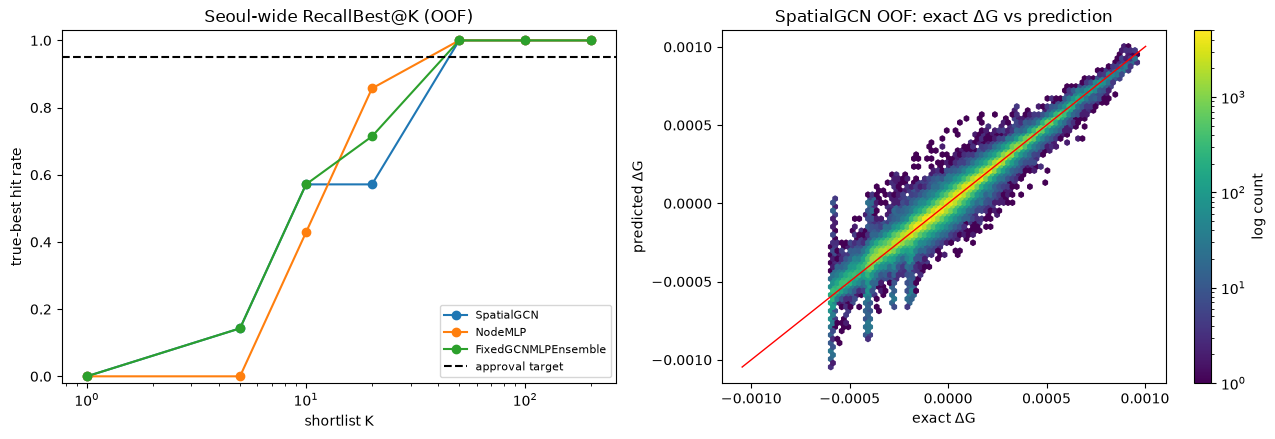


**실용성 판정:** GCN 회귀 적합도는 `R²=0.966`로 높지만, 서울 전체
top-20은 7개 시나리오 중 **3개에서 실제 1위를 놓쳤다**.
K=50에서는 저장된 7개 시나리오의 실제 1위를 모두 포함했으나, 같은 OOF
결과를 본 뒤 발견한 operating point이고 95% 이항구간 하한도
`0.590`에 불과하다. 따라서 K=50은 후속 독립검증 대상일 뿐 새 승인
기준이 아니다. 더 단순한 NodeMLP가 GCN보다 MAE와 서울전체 top-20 포착에서
더 좋아 **그래프의 증분가치도 입증되지 않았다**. 어떤 K에서도 shortlist 내부
exact 재평가를 생략할 수 없다.


In [16]:
from scipy.stats import beta, spearmanr
from sklearn.metrics import r2_score

gcn_oof = original_oof["gcn"]
gids = training_tensor["gids"]
scenario_names = training_tensor["scenario_names"]
scenario_policy_rows = []

for scenario_index, scenario_name in enumerate(scenario_names):
    actual = truth[scenario_index]
    predicted = gcn_oof[scenario_index]
    actual_order = np.argsort(-actual, kind="mergesort")
    predicted_order = np.argsort(-predicted, kind="mergesort")
    actual_best_index = int(actual_order[0])
    predicted_rank = int(np.flatnonzero(predicted_order == actual_best_index)[0] + 1)
    predicted_top20 = predicted_order[:20]
    exact_best_inside_top20 = int(
        predicted_top20[np.argmax(actual[predicted_top20])]
    )
    absolute_regret = float(
        actual[actual_best_index] - actual[exact_best_inside_top20]
    )
    relative_regret = absolute_regret / max(
        abs(float(actual[actual_best_index])), 1e-12
    )
    scenario_policy_rows.append(
        {
            "시나리오": str(scenario_name),
            "실제 1위 gid": str(gids[actual_best_index]),
            "GCN 예측순위": predicted_rank,
            "top20 포함": predicted_rank <= 20,
            "top50 포함": predicted_rank <= 50,
            "실제 1위 ΔG": float(actual[actual_best_index]),
            "top20 exact 최상 gid": str(gids[exact_best_inside_top20]),
            "top20 exact 최상 ΔG": float(actual[exact_best_inside_top20]),
            "상대 regret@20": relative_regret,
            "실제/예측 top20 교집합률": (
                len(set(actual_order[:20]).intersection(predicted_order[:20])) / 20
            ),
            "MAE": float(np.mean(np.abs(actual - predicted))),
            "RMSE": float(np.sqrt(np.mean(np.square(actual - predicted)))),
            "R²": float(r2_score(actual, predicted)),
            "Spearman": float(spearmanr(actual, predicted).statistic),
        }
    )

gcn_scenario_policy = pd.DataFrame(scenario_policy_rows)
display(gcn_scenario_policy)

citywide_k_values = (1, 5, 10, 20, 50, 100, 200)
citywide_curves = {
    model_name: ranking_curve(
        truth,
        prediction,
        seoul_group,
        top_k_values=citywide_k_values,
        random_seed=manifest["config"]["random_seed"],
    )
    for model_name, prediction, _ in oof_specs
}
citywide_curve_rows = []
for model_name, curve in citywide_curves.items():
    for k in citywide_k_values:
        item = curve[str(k)]
        citywide_curve_rows.append(
            {
                "모델": model_name,
                "K": k,
                "Recall@K": item["recall_at_k"],
                "RecallBest@K": item["best_in_predicted_top_k"],
                "평균 상대 regret@K": item["relative_policy_regret"],
                "상대 regret p95@K": item["relative_policy_regret_p95"],
            }
        )
citywide_curve_table = pd.DataFrame(citywide_curve_rows)
display(
    citywide_curve_table.loc[
        (citywide_curve_table["모델"] == "SpatialGCN")
        & citywide_curve_table["K"].isin([10, 20, 50, 100])
    ]
)

regression_comparison_rows = []
for model_name, prediction, _ in oof_specs:
    model_mae = float(np.mean(np.abs(truth - prediction)))
    regression_comparison_rows.append(
        {
            "모델": model_name,
            "MAE": model_mae,
            "RMSE": float(np.sqrt(np.mean(np.square(truth - prediction)))),
            "R²": float(r2_score(truth.ravel(), prediction.ravel())),
            "Spearman": float(spearmanr(truth.ravel(), prediction.ravel()).statistic),
        }
    )
regression_comparison = pd.DataFrame(regression_comparison_rows)
gcn_comparison_mae = float(
    regression_comparison.loc[
        regression_comparison["모델"] == "SpatialGCN", "MAE"
    ].iloc[0]
)
regression_comparison["GCN 대비 MAE 개선(%)"] = (
    100.0 * (gcn_comparison_mae - regression_comparison["MAE"]) / gcn_comparison_mae
)
display(regression_comparison)


def true_best_rank_distribution(
    actual_values: np.ndarray,
    predicted_values: np.ndarray,
    evaluation_groups: np.ndarray,
) -> np.ndarray:
    ranks = []
    evaluation_groups = np.asarray(evaluation_groups)
    for group_name in pd.unique(evaluation_groups):
        group_indices = np.flatnonzero(evaluation_groups == group_name)
        for scenario_index in range(actual_values.shape[0]):
            group_actual = actual_values[scenario_index, group_indices]
            group_prediction = predicted_values[scenario_index, group_indices]
            local_best = int(np.argmax(group_actual))
            predicted_order = np.argsort(-group_prediction, kind="mergesort")
            ranks.append(int(np.flatnonzero(predicted_order == local_best)[0] + 1))
    return np.asarray(ranks, dtype=int)


rank_population_rows = []
for population_name, evaluation_groups in [
    ("자치구×시나리오", groups),
    ("외부fold×시나리오", fold_labels),
    ("서울전체×시나리오", seoul_group),
]:
    ranks = true_best_rank_distribution(truth, gcn_oof, evaluation_groups)
    sorted_ranks = np.sort(ranks)
    k_for_95 = int(sorted_ranks[int(np.ceil(0.95 * len(ranks))) - 1])
    rank_population_rows.append(
        {
            "평가 모집단": population_name,
            "단위": len(ranks),
            "K=20 hit": int((ranks <= 20).sum()),
            "RecallBest@20": float(np.mean(ranks <= 20)),
            "관측 RecallBest≥0.95 최소 K": k_for_95,
            "관측 전단위 100% 최소 K": int(ranks.max()),
        }
    )
gcn_rank_population = pd.DataFrame(rank_population_rows)
display(gcn_rank_population)

gcn_mae = float(np.mean(np.abs(truth - gcn_oof)))
gcn_rmse = float(np.sqrt(np.mean(np.square(truth - gcn_oof))))
gcn_r2 = float(r2_score(truth.ravel(), gcn_oof.ravel()))
target_mean_absolute = float(np.mean(np.abs(truth)))
target_std = float(np.std(truth))
gcn_signal_table = pd.DataFrame(
    [
        ("OOF MAE", gcn_mae),
        ("OOF RMSE", gcn_rmse),
        ("OOF R²", gcn_r2),
        ("target |ΔG| 평균", target_mean_absolute),
        ("target 표준편차", target_std),
        ("MAE / target |ΔG| 평균", gcn_mae / target_mean_absolute),
        ("MAE / target 표준편차", gcn_mae / target_std),
    ],
    columns=["회귀 진단", "값"],
)
display(gcn_signal_table)

ranking_resolution_rows = []
for scenario_index, scenario_name in enumerate(scenario_names):
    actual = truth[scenario_index]
    predicted = gcn_oof[scenario_index]
    actual_top20 = np.argsort(-actual, kind="mergesort")[:20]
    exact_gap_1_to_20 = float(actual[actual_top20[0]] - actual[actual_top20[-1]])
    top20_mae = float(
        np.mean(np.abs(actual[actual_top20] - predicted[actual_top20]))
    )
    ranking_resolution_rows.append(
        {
            "시나리오": str(scenario_name),
            "exact 1위-20위 ΔG gap": exact_gap_1_to_20,
            "전체 후보 GCN MAE": float(np.mean(np.abs(actual - predicted))),
            "실제 top20 GCN MAE": top20_mae,
            "전체 MAE / 1-20위 gap": (
                float(np.mean(np.abs(actual - predicted)))
                / max(exact_gap_1_to_20, 1e-15)
            ),
        }
    )
ranking_resolution = pd.DataFrame(ranking_resolution_rows)
display(ranking_resolution)

tail_error_rows = []
for quantile in [0.0, 0.9, 0.99, 0.999]:
    errors = []
    selected_count = 0
    for scenario_index in range(truth.shape[0]):
        cutoff = np.quantile(truth[scenario_index], quantile)
        selected = truth[scenario_index] >= cutoff
        errors.extend(
            np.abs(
                truth[scenario_index, selected]
                - gcn_oof[scenario_index, selected]
            )
        )
        selected_count += int(selected.sum())
    tail_error_rows.append(
        {
            "실제 target 분위 이상": quantile,
            "평가점": selected_count,
            "MAE": float(np.mean(errors)),
            "절대오차 p95": float(np.quantile(errors, 0.95)),
        }
    )
display(pd.DataFrame(tail_error_rows))

gcn_k20_hits = int(gcn_scenario_policy["top20 포함"].sum())
gcn_k50_hits = int(gcn_scenario_policy["top50 포함"].sum())


def clopper_pearson(successes: int, trials: int, alpha: float = 0.05):
    low = 0.0 if successes == 0 else float(
        beta.ppf(alpha / 2, successes, trials - successes + 1)
    )
    high = 1.0 if successes == trials else float(
        beta.ppf(1 - alpha / 2, successes + 1, trials - successes)
    )
    return low, high


k20_ci = clopper_pearson(gcn_k20_hits, len(gcn_scenario_policy))
k50_ci = clopper_pearson(gcn_k50_hits, len(gcn_scenario_policy))
display(
    pd.DataFrame(
        [
            ("K=20", gcn_k20_hits, len(gcn_scenario_policy), gcn_k20_hits / 7, *k20_ci),
            ("K=50", gcn_k50_hits, len(gcn_scenario_policy), gcn_k50_hits / 7, *k50_ci),
        ],
        columns=["운영점", "실제1위 포함", "시나리오", "비율", "95% CI 하한", "95% CI 상한"],
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for model_name in ["SpatialGCN", "NodeMLP", "FixedGCNMLPEnsemble"]:
    model_curve = citywide_curve_table.loc[
        citywide_curve_table["모델"] == model_name
    ]
    axes[0].plot(
        model_curve["K"],
        model_curve["RecallBest@K"],
        marker="o",
        label=model_name,
    )
axes[0].axhline(
    thresholds["min_recall_best_at_20"],
    color="black",
    linestyle="--",
    label="approval target",
)
axes[0].set_xscale("log")
axes[0].set_ylim(-0.02, 1.03)
axes[0].set_title("Seoul-wide RecallBest@K (OOF)")
axes[0].set_xlabel("shortlist K")
axes[0].set_ylabel("true-best hit rate")
axes[0].legend(fontsize=8)

hexbin = axes[1].hexbin(
    truth.ravel(),
    gcn_oof.ravel(),
    gridsize=70,
    bins="log",
    mincnt=1,
    cmap="viridis",
)
line_min = float(min(truth.min(), gcn_oof.min()))
line_max = float(max(truth.max(), gcn_oof.max()))
axes[1].plot([line_min, line_max], [line_min, line_max], color="red", linewidth=1)
axes[1].set_title("SpatialGCN OOF: exact ΔG vs prediction")
axes[1].set_xlabel("exact ΔG")
axes[1].set_ylabel("predicted ΔG")
fig.colorbar(hexbin, ax=axes[1], label="log count")
plt.tight_layout()
plt.show()

assert gcn_k20_hits == 4
assert gcn_k50_hits == 7
assert gcn_scenario_policy["GCN 예측순위"].max() == 35
assert gcn_r2 > 0.96
assert int((gcn_scenario_policy["GCN 예측순위"] == 1).sum()) == 0
assert regression_comparison.loc[
    regression_comparison["모델"] == "NodeMLP", "MAE"
].iloc[0] < gcn_mae

display(
    Markdown(
        f'''
**실용성 판정:** GCN 회귀 적합도는 `R²={gcn_r2:.3f}`로 높지만, 서울 전체
top-20은 7개 시나리오 중 **{7 - gcn_k20_hits}개에서 실제 1위를 놓쳤다**.
K=50에서는 저장된 7개 시나리오의 실제 1위를 모두 포함했으나, 같은 OOF
결과를 본 뒤 발견한 operating point이고 95% 이항구간 하한도
`{k50_ci[0]:.3f}`에 불과하다. 따라서 K=50은 후속 독립검증 대상일 뿐 새 승인
기준이 아니다. 더 단순한 NodeMLP가 GCN보다 MAE와 서울전체 top-20 포착에서
더 좋아 **그래프의 증분가치도 입증되지 않았다**. 어떤 K에서도 shortlist 내부
exact 재평가를 생략할 수 없다.
'''
    )
)

## 11. 실제 모델 가중치 로드 및 추론

저장된 GCN과 개선 MLP 체크포인트를 CPU에서 로드하고, 7개 시나리오×52,736개 후보 전체에 forward pass를 수행한다. 이 검증은 “모델 파일이 깨지지 않았고 실제로 정상 추론한다”는 뜻이지, 앞 절의 승인 게이트 실패를 뒤집는 것은 아니다.

In [17]:
import torch

from elder_guardian.surrogate import NodeMLP, SpatialGCN, normalized_spatial_adjacency

features = training_tensor["features"]
xy = training_tensor["xy"]
model_groups = training_tensor["groups"]
adjacency_coo = normalized_spatial_adjacency(xy, model_groups)
adjacency_indices = torch.tensor(
    np.vstack([adjacency_coo.row, adjacency_coo.col]), dtype=torch.long
)
adjacency_values = torch.tensor(adjacency_coo.data, dtype=torch.float32)
adjacency = torch.sparse_coo_tensor(
    adjacency_indices,
    adjacency_values,
    adjacency_coo.shape,
    check_invariants=True,
).coalesce()


def standardized_features(checkpoint: dict) -> torch.Tensor:
    mean = np.asarray(checkpoint["feature_mean"], dtype=np.float32)
    scale = np.asarray(checkpoint["feature_scale"], dtype=np.float32)
    return torch.tensor((features - mean) / scale, dtype=torch.float32)


inference_rows = []

gcn_checkpoint = torch.load(
    ARTIFACTS / "gnn_surrogate.pt", map_location="cpu", weights_only=True
)
gcn = SpatialGCN(
    gcn_checkpoint["input_dim"],
    gcn_checkpoint["hidden_dim"],
    gcn_checkpoint["dropout"],
)
gcn.load_state_dict(gcn_checkpoint["state_dict"], strict=True)
gcn.eval()
with torch.no_grad():
    gcn_prediction = gcn(standardized_features(gcn_checkpoint), adjacency).numpy()
    gcn_prediction = (
        gcn_prediction * gcn_checkpoint["target_scale"] + gcn_checkpoint["target_mean"]
    )
inference_rows.append(
    {
        "모델": "SpatialGCN",
        "출력 shape": str(gcn_prediction.shape),
        "유한값": bool(np.isfinite(gcn_prediction).all()),
        "최솟값": float(gcn_prediction.min()),
        "최댓값": float(gcn_prediction.max()),
        "파라미터 텐서": len(gcn_checkpoint["state_dict"]),
    }
)

mlp_checkpoint = torch.load(
    ARTIFACTS / "mlp_surrogate.pt", map_location="cpu", weights_only=True
)
mlp = NodeMLP(
    mlp_checkpoint["input_dim"],
    mlp_checkpoint["hidden_dim"],
    mlp_checkpoint["dropout"],
)
mlp.load_state_dict(mlp_checkpoint["state_dict"], strict=True)
mlp.eval()
with torch.no_grad():
    mlp_prediction = mlp(standardized_features(mlp_checkpoint)).numpy()
    mlp_prediction = (
        mlp_prediction * mlp_checkpoint["target_scale"] + mlp_checkpoint["target_mean"]
    )
inference_rows.append(
    {
        "모델": "NodeMLP",
        "출력 shape": str(mlp_prediction.shape),
        "유한값": bool(np.isfinite(mlp_prediction).all()),
        "최솟값": float(mlp_prediction.min()),
        "최댓값": float(mlp_prediction.max()),
        "파라미터 텐서": len(mlp_checkpoint["state_dict"]),
    }
)

assert gcn_prediction.shape == truth.shape == (7, 52_736)
assert mlp_prediction.shape == truth.shape
assert np.isfinite(gcn_prediction).all()
assert np.isfinite(mlp_prediction).all()
display(pd.DataFrame(inference_rows))

,모델,출력 shape,유한값,최솟값,최댓값,파라미터 텐서
0,SpatialGCN,"(7, 52736)",True,-0.00073248922,0.00097965507,6
1,NodeMLP,"(7, 52736)",True,-0.00063035684,0.00094637816,8


### 11.1 최종 checkpoint와 OOF 성능의 구분

공간 OOF 성능은 fold마다 학습한 뒤 폐기된 모델에서 나온다. 저장된 `gnn_surrogate.pt`는 전체 exact 라벨로 160 epoch 고정 재학습한 별도 모델이며, OOF best-state가 아니다. 아래 동일 학습표본 비교는 checkpoint integration smoke test일 뿐 외부성능이 아니다.

In [18]:
final_checkpoint_rank_rows = []
for scenario_index, scenario_name in enumerate(scenario_names):
    actual = truth[scenario_index]
    final_prediction = gcn_prediction[scenario_index]
    actual_best_index = int(np.argmax(actual))
    final_order = np.argsort(-final_prediction, kind="mergesort")
    final_rank = int(np.flatnonzero(final_order == actual_best_index)[0] + 1)
    final_checkpoint_rank_rows.append(
        {
            "시나리오": str(scenario_name),
            "실제 1위 gid": str(gids[actual_best_index]),
            "최종 checkpoint 예측순위": final_rank,
            "top20 포함": final_rank <= 20,
            "top50 포함": final_rank <= 50,
            "평가 성격": "학습내 smoke test",
        }
    )
final_checkpoint_ranks = pd.DataFrame(final_checkpoint_rank_rows)
display(final_checkpoint_ranks)

assert final_checkpoint_ranks["top20 포함"].sum() == 5
assert final_checkpoint_ranks["top50 포함"].all()

,시나리오,실제 1위 gid,최종 checkpoint 예측순위,top20 포함,top50 포함,평가 성격
0,legal20_walk10_new20,다사637437,13,True,True,학습내 smoke test
1,legal20_walk15_new20,다사639440,4,True,True,학습내 smoke test
2,legal20_walk15_new40_BASE,다사638441,5,True,True,학습내 smoke test
3,legal20_walk15_new60,다사640506,43,False,True,학습내 smoke test
4,legal20_walk20_new40,다사641507,8,True,True,학습내 smoke test
5,historical_reference_walk15_new40,다사642505,21,False,True,학습내 smoke test
6,legal20_walk15_new40_1km_residual,다사638441,5,True,True,학습내 smoke test


### 11.2 CPU 실측 속도와 운영비용

checkpoint가 정상이라는 사실과 서비스에서 유용하다는 사실은 다르다. 아래 benchmark는 이미 만들어진 19개 feature tensor와 graph를 사용하는 순수 추론 경로를 반복 측정한다. 원자료 정제, 기준 E2SFCA, 19개 feature 생성과 필지·교통 검증 시간은 포함하지 않는다.

In [19]:
import time

from elder_guardian.exact import evaluate_candidates_exact
from elder_guardian.features import FEATURE_COLUMNS, build_candidate_features

gcn_input = standardized_features(gcn_checkpoint)

checkpoint_load_seconds = []
for _ in range(10):
    start = time.perf_counter()
    loaded_checkpoint = torch.load(
        ARTIFACTS / "gnn_surrogate.pt",
        map_location="cpu",
        weights_only=True,
    )
    checkpoint_load_seconds.append(time.perf_counter() - start)

graph_build_seconds = []
for _ in range(5):
    start = time.perf_counter()
    benchmark_graph = normalized_spatial_adjacency(xy, model_groups)
    graph_build_seconds.append(time.perf_counter() - start)

with torch.no_grad():
    _ = gcn(gcn_input, adjacency)
forward_seconds = []
forward_outputs = []
for _ in range(20):
    start = time.perf_counter()
    with torch.no_grad():
        output = gcn(gcn_input, adjacency).numpy()
    forward_seconds.append(time.perf_counter() - start)
    forward_outputs.append(output)

determinism_error = max(
    float(np.max(np.abs(output - forward_outputs[0])))
    for output in forward_outputs[1:]
)
exact_base_seconds = float(base["exact_runtime_seconds"])
exact_all_scenarios_seconds = float(scenario_df["exact_runtime_seconds"].sum())
median_forward_seconds = float(np.median(forward_seconds))
median_graph_seconds = float(np.median(graph_build_seconds))
median_checkpoint_seconds = float(np.median(checkpoint_load_seconds))
gcn_fit_seconds = float(
    surrogate_table.loc[
        surrogate_table["model"] == "SpatialGCN", "fit_seconds"
    ].iloc[0]
)

base_scenario_config = next(
    scenario
    for scenario in manifest["config"]["scenarios"]
    if scenario["name"] == manifest["config"]["base_scenario"]
)
start = time.perf_counter()
fresh_base_features = build_candidate_features(
    population,
    facilities,
    base_scenario_config,
    speed_m_per_min=manifest["config"]["walking_speed_m_per_min"],
)
fresh_feature_seconds = time.perf_counter() - start

population_position_by_gid = pd.Series(
    np.arange(len(population)), index=population["gid"]
)
common_positions = population_position_by_gid.loc[gids].to_numpy()
fresh_common_features = fresh_base_features.features.iloc[common_positions][
    FEATURE_COLUMNS
].to_numpy(dtype=np.float32)[None, :, :]
fresh_standardized = torch.tensor(
    (
        fresh_common_features
        - np.asarray(gcn_checkpoint["feature_mean"], dtype=np.float32)
    )
    / np.asarray(gcn_checkpoint["feature_scale"], dtype=np.float32),
    dtype=torch.float32,
)
start = time.perf_counter()
with torch.no_grad():
    fresh_base_prediction = gcn(fresh_standardized, adjacency).numpy()[0]
fresh_base_prediction = (
    fresh_base_prediction * gcn_checkpoint["target_scale"]
    + gcn_checkpoint["target_mean"]
)
fresh_base_forward_seconds = time.perf_counter() - start

predicted_top50 = np.argsort(
    -fresh_base_prediction, kind="mergesort"
)[:50]
fresh_demand = population.iloc[fresh_base_features.demand_index]
start = time.perf_counter()
top50_exact = evaluate_candidates_exact(
    fresh_base_features.baseline_demand_accessibility,
    fresh_base_features.demand_population,
    fresh_demand[["x", "y"]].to_numpy(dtype=float),
    xy[predicted_top50],
    new_capacity=base_scenario_config["new_capacity"],
    speed_m_per_min=manifest["config"]["walking_speed_m_per_min"],
    tau_minutes=base_scenario_config["tau_minutes"],
    cutoff_minutes=base_scenario_config["cutoff_minutes"],
)
top50_exact_seconds = time.perf_counter() - start
top50_best_position = int(np.nanargmax(top50_exact.delta_gini))
top50_exact_best_gid = str(gids[predicted_top50[top50_best_position]])

hybrid_query_seconds = (
    fresh_feature_seconds
    + median_graph_seconds
    + fresh_base_forward_seconds
    + top50_exact_seconds
)
full_exact_query_seconds = fresh_feature_seconds + exact_base_seconds
hybrid_speedup = full_exact_query_seconds / hybrid_query_seconds
training_break_even_queries = gcn_fit_seconds / max(
    full_exact_query_seconds - hybrid_query_seconds, 1e-12
)

predict_gnn_path = MODELING / "scripts" / "predict_gnn.py"
predict_gnn_source = predict_gnn_path.read_text(encoding="utf-8")
gnn_cli_run = subprocess.run(
    [
        sys.executable,
        str(predict_gnn_path),
        "--artifacts",
        str(ARTIFACTS),
        "--scenario",
        manifest["config"]["base_scenario"],
        "--top",
        "3",
    ],
    cwd=ROOT,
    capture_output=True,
    text=True,
)
has_gcn_cli = (
    predict_gnn_path.is_file()
    and "gnn_surrogate.pt" in predict_gnn_source
    and "SpatialGCN" in predict_gnn_source
    and "exact E2SFCA/Gini re-evaluation is mandatory" in predict_gnn_source
    and gnn_cli_run.returncode == 0
    and "SCREENING_ONLY_NOT_APPROVED_AT_K20" in gnn_cli_run.stdout
)

runtime_table = pd.DataFrame(
    [
        ("checkpoint load 중앙값", median_checkpoint_seconds, "초"),
        ("graph 생성 중앙값", median_graph_seconds, "초"),
        ("7×52,736 full forward 중앙값", median_forward_seconds, "초"),
        ("full forward p95", float(np.quantile(forward_seconds, 0.95)), "초"),
        ("forward 반복 최대차", determinism_error, "ΔG scale"),
        ("기본 시나리오 exact 전체후보", exact_base_seconds, "초"),
        ("7개 시나리오 exact 합계", exact_all_scenarios_seconds, "초"),
        ("exact 합계 / GCN forward", exact_all_scenarios_seconds / median_forward_seconds, "배"),
        ("fresh base feature 생성", fresh_feature_seconds, "초"),
        ("fresh base 1-scenario forward", fresh_base_forward_seconds, "초"),
        ("예측 top-50 exact 재평가", top50_exact_seconds, "초"),
        ("fresh hybrid 추정 합계", hybrid_query_seconds, "초"),
        ("fresh feature+전체 exact", full_exact_query_seconds, "초"),
        ("fresh end-to-end 절감", hybrid_speedup, "배"),
        ("GCN 공간 OOF 학습", gcn_fit_seconds, "초"),
        ("학습비용 상쇄 질의수", training_break_even_queries, "base 질의"),
        ("feature tensor 메모리", features.nbytes / (1024**2), "MiB"),
        ("checkpoint 크기", (ARTIFACTS / "gnn_surrogate.pt").stat().st_size / 1024, "KiB"),
        ("GNN 전용 predict CLI", has_gcn_cli, "존재 여부"),
        ("GNN CLI smoke returncode", gnn_cli_run.returncode, "0=정상"),
        ("PyTorch CPU thread", torch.get_num_threads(), "개"),
    ],
    columns=["실측 항목", "값", "단위"],
)
display(runtime_table)

assert determinism_error == 0.0
assert median_forward_seconds < exact_base_seconds
assert has_gcn_cli is True
assert top50_exact_best_gid == str(base["best_gid"])
assert hybrid_speedup > 1.0

display(
    Markdown(
        f'''
순수 forward는 exact보다 매우 빠르지만, 새 입력에서는 feature 생성이
`{fresh_feature_seconds:.2f}초`를 차지한다. base 기준 hybrid는 약
`{hybrid_query_seconds:.2f}초`, feature+전체 exact는 약
`{full_exact_query_seconds:.2f}초`로 실제 절감은 **{hybrid_speedup:.2f}배**다.
단발성 서울 분석에서는 이 절감을 위해 승인되지 않은 top-20을 사용할 이유가
약하다. 반복 시나리오가 많거나 다중교통 exact가 훨씬 비싸질 때 broad
shortlist의 가치가 커진다. 체크섬·입력계약·유한값을 확인하는 제한형 GNN
CLI를 추가했지만 저장된 7개 tensor만 처리하며 exact 재평가를 자동화하지
않으므로 아직 운영 API는 아니다.
'''
    )
)

,실측 항목,값,단위
0,checkpoint load 중앙값,0.0005191665,초
1,graph 생성 중앙값,0.040840958,초
2,"7×52,736 full forward 중앙값",0.050133417,초
3,full forward p95,0.051923604,초
4,forward 반복 최대차,0,ΔG scale
5,기본 시나리오 exact 전체후보,4.8063152,초
6,7개 시나리오 exact 합계,35.025142,초
7,exact 합계 / GCN forward,698.63864,배
8,fresh base feature 생성,4.2904593,초
9,fresh base 1-scenario forward,0.017088542,초



순수 forward는 exact보다 매우 빠르지만, 새 입력에서는 feature 생성이
`4.29초`를 차지한다. base 기준 hybrid는 약
`4.36초`, feature+전체 exact는 약
`9.10초`로 실제 절감은 **2.08배**다.
단발성 서울 분석에서는 이 절감을 위해 승인되지 않은 top-20을 사용할 이유가
약하다. 반복 시나리오가 많거나 다중교통 exact가 훨씬 비싸질 때 broad
shortlist의 가치가 커진다. 체크섬·입력계약·유한값을 확인하는 제한형 GNN
CLI를 추가했지만 저장된 7개 tensor만 처리하며 exact 재평가를 자동화하지
않으므로 아직 운영 API는 아니다.


## 12. 코드 테스트와 산출물 체크섬 재실행

테스트는 notebook 실행 위치와 무관하도록 `modeling/src`를 `PYTHONPATH`에 명시한다. 체크섬 검증은 run manifest에 등록된 파일이 생성 이후 바뀌거나 손상됐는지 확인한다.

In [20]:
test_environment = os.environ.copy()
test_environment["PYTHONPATH"] = str(MODELING / "src")
test_run = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", str(MODELING / "tests")],
    cwd=ROOT,
    env=test_environment,
    capture_output=True,
    text=True,
)
print(test_run.stdout)
if test_run.stderr:
    print(test_run.stderr)
assert test_run.returncode == 0, "pytest 실패"

............................                                             [100%]



In [21]:
verify_run = subprocess.run(
    [
        sys.executable,
        str(MODELING / "scripts" / "verify.py"),
        "--artifacts",
        str(ARTIFACTS),
    ],
    cwd=ROOT,
    capture_output=True,
    text=True,
)
print(verify_run.stdout)
if verify_run.stderr:
    print(verify_run.stderr)
assert verify_run.returncode == 0, "artifact checksum 검증 실패"
assert "0 checksum mismatches" in verify_run.stdout

verified 54 files; 0 checksum mismatches



### 12.1 배포 묶음과 문서 버전 대조

live canonical 디렉터리의 체크섬 통과와 별개로, 전달용 tar.gz가 같은 개선 버전인지 확인한다. 개선 MLP와 재조정 스크립트가 빠진 과거 스냅샷을 “improved”로 전달하면 성능표를 재현할 수 없다.

In [22]:
import re
import tarfile

archive_path = MODELING / "artifacts" / "elder_guardian_model_run_20260727_improved.tar.gz"
required_archive_members = {
    "modeling/GNN_MODEL_CARD.md",
    "modeling/scripts/predict_gnn.py",
    "modeling/scripts/retune_surrogate.py",
    "modeling/artifacts/run_20260727_improved/gnn_deployment_contract.json",
    "modeling/artifacts/run_20260727_improved/mlp_surrogate.pt",
    "modeling/artifacts/run_20260727_improved/surrogate_ensemble.json",
    "modeling/artifacts/run_20260727_improved/surrogate_improvement.json",
    "modeling/artifacts/run_20260727_improved/surrogate_improvement_oof.npz",
}

with tarfile.open(archive_path, "r:gz") as archive:
    member_names = set(archive.getnames())
    missing_archive_members = sorted(required_archive_members - member_names)
    archived_manifest_member = archive.extractfile(
        "modeling/artifacts/run_20260727_improved/run_manifest.json"
    )
    archived_manifest = json.load(archived_manifest_member)
    archived_surrogate_member = archive.extractfile(
        "modeling/src/elder_guardian/surrogate.py"
    )
    archived_surrogate_hash = hashlib.sha256(archived_surrogate_member.read()).hexdigest()

live_surrogate_hash = sha256_file(MODELING / "src" / "elder_guardian" / "surrogate.py")
archive_current = (
    not missing_archive_members
    and archived_surrogate_hash == live_surrogate_hash
    and len(archived_manifest["artifact_hashes"]) == len(manifest["artifact_hashes"])
    and len(archived_manifest["sources"]["modeling_code_hashes"])
    == len(manifest["sources"]["modeling_code_hashes"])
)

readme_text = (MODELING / "README.md").read_text(encoding="utf-8")
readme_spearman_match = re.search(
    r"Spearman[^0-9]*([0-9]+\.[0-9]+)", readme_text
)
readme_spearman = (
    float(readme_spearman_match.group(1)) if readme_spearman_match else float("nan")
)
configured_spearman = float(thresholds["min_spearman"])

display(
    pd.DataFrame(
        [
            ("배포 tar SHA-256", sha256_file(archive_path)),
            ("tar artifact hash 수", len(archived_manifest["artifact_hashes"])),
            ("live artifact hash 수", len(manifest["artifact_hashes"])),
            ("tar source hash 수", len(archived_manifest["sources"]["modeling_code_hashes"])),
            ("live source hash 수", len(manifest["sources"]["modeling_code_hashes"])),
            ("필수 누락 member", ", ".join(missing_archive_members) or "없음"),
            ("surrogate.py live와 일치", archived_surrogate_hash == live_surrogate_hash),
            ("배포 묶음 최신", archive_current),
            ("README Spearman 기준", readme_spearman),
            ("config/manifest Spearman 기준", configured_spearman),
            ("문서-설정 기준 일치", np.isclose(readme_spearman, configured_spearman)),
        ],
        columns=["배포 감사", "결과"],
    )
)

,배포 감사,결과
0,배포 tar SHA-256,3d6596a63b6ab4b8ddeda07547844a81e65741b3a3ff22f4c8c7ba2bc73f6e1e
1,tar artifact hash 수,26
2,live artifact hash 수,26
3,tar source hash 수,28
4,live source hash 수,28
5,필수 누락 member,없음
6,surrogate.py live와 일치,True
7,배포 묶음 최신,True
8,README Spearman 기준,0.85
9,config/manifest Spearman 기준,0.85


## 13. 최종 검증표와 해석

In [23]:
scorecard = pd.DataFrame(
    [
        ("PDF 14쪽 전체 렌더·내용 대조", "통과", "페이지/해시 기록, 요구사항 매트릭스 작성"),
        ("데이터 행수·중복·총합·식별자", "통과", "61,652 격자, 3,644 시설, exact 404,054행"),
        ("E2SFCA 도달공급 보존식", "통과", f"실데이터 최대오차 {scenario_df['conservation_error'].max():.3e}"),
        ("기존시설 분모0 오류 분리", "부분 실패", "walk10에서 1시설·정원20 누락, 기존 gate가 미검출"),
        ("exact 국소갱신 vs brute-force", "통과", "소형 예제 절대차 < 1e-14"),
        ("전체 후보 반복실행", "통과", "404,054행 Gini/ΔG 최대차이 0"),
        ("저장 모델 로드·전체 forward", "통과", "GCN/MLP 모두 (7, 52,736), 유한 출력"),
        ("OOF 성능표 독립 재계산", "통과", "4개 모델 저장지표와 최대차이 < 1e-12"),
        ("SpatialGCN 회귀 근사", "통과", f"OOF R²={gcn_r2:.3f}, MAE={gcn_mae:.3e}"),
        ("SpatialGCN 서울전체 top-20", "실패", f"실제 1위 {gcn_k20_hits}/7 포함; 3개 시나리오 누락"),
        ("SpatialGCN 서울전체 top-50", "실험적", f"7/7 포함, 사후 발견·95% CI 하한 {k50_ci[0]:.3f}"),
        ("서울전체 GCN/MLP shortlist", "실패", f"최고 RecallBest@20={policy_metrics['서울전체 RecallBest@20'].max():.3f} < 0.95"),
        ("SpatialGCN 순수 추론", "통과", f"7×52,736 forward 중앙값 {median_forward_seconds:.3f}초"),
        ("GNN 제한형 CLI", "통과", "체크섬·shape·feature/scenario 순서·유한값 검증"),
        ("GNN 운영 경로", "미완료", "새 원자료 feature API와 exact 자동 재평가 필요"),
        ("공간 CV 버퍼", "실패", f"train-test 최소 {buffer_audit['train까지 최소거리(m)'].min():.0f}m; 연속 블록/LODO 아님"),
        ("순위손실·교통 그래프 edge", "미구현", "top-emphasized Huber 회귀와 물리 인접 edge만 사용"),
        ("현행 정원 회귀 배치", "기각", "검증 현행정원 0건, Spearman 0.086, 기준모델 우위 없음"),
        ("다중교통 일반화비용", "미구현", "현재 도보 직선거리 대체값"),
        ("필지·예산·법규 최종 타당성", "미구현", "후보는 100m 셀; exact 1위 중심점은 도로 증거"),
        ("전달용 tar와 live 버전", "통과" if archive_current else "실패", "누락 없음·해시 일치" if archive_current else "개선 MLP/소스가 빠진 이전 스냅샷"),
        ("정책 배치", "불가", "SCREENING_ONLY_NOT_POLICY_DEPLOYABLE"),
    ],
    columns=["검증 항목", "판정", "근거"],
)
display(scorecard)

best_surrogate = surrogate_table.sort_values(
    ["best_in_predicted_top_k", "relative_policy_regret"], ascending=[False, True]
).iloc[0]
display(
    Markdown(
        f'''
### 결론

1. **정확 계산 수학과 기본 시나리오는 정상이다.** 수식, 도달공급 보존식, 테스트 26개, 전체 후보 반복실행, 체크섬을 통과했고 기본 시나리오의 기존시설 분모 0도 없다. 전체 후보 평가는 **{base['exact_runtime_seconds']:.2f}초**였다.
2. **walk10 민감도 시나리오는 재실행이 필요하다.** 기존시설 1곳의 분모가 0이라 정원 20명이 조용히 도달공급에서 제외됐지만 기존 gate가 이를 잡지 못했다.
3. **SpatialGCN은 회귀모델로는 강하지만 top-20 추천기로는 부족하다.** OOF `R²={gcn_r2:.3f}`이지만 서울 전체 실제 1위를 **{gcn_k20_hits}/7**만 포함했다. K=50의 7/7 결과는 사후 발견이고 외부 검증이 없어 승인 근거로 쓸 수 없다.
4. **GNN은 제한적 가속기로만 가능하다.** 순수 forward는 빠르지만 exact도 기본 시나리오를 **{base['exact_runtime_seconds']:.2f}초**에 끝낸다. 제한형 CLI는 정상 실행하지만 저장된 tensor만 점수화하며 모든 shortlist는 exact로 재평가해야 한다.
5. **다른 대리모델도 승인되지 않았다.** 자치구 내부 최고 `{best_surrogate['model']}`의 `RecallBest@20`은 **{best_surrogate['best_in_predicted_top_k']:.3f}**, 서울 전체 최고값은 **{policy_metrics['서울전체 RecallBest@20'].max():.3f}**로 기준 0.95보다 낮다.
6. **기본 시나리오의 형평성 개선은 작다.** 최상 후보의 상대 Gini 감소는 **{base['relative_gini_reduction_pct']:.3f}%**다.
7. **현재 결과는 정책 확정안이 아니다.** 현행 정원, 도로망·대중교통 OD, 필지·지가·건축비·법적 가능성을 결합하기 전에는 설치 위치나 기대효과를 확정할 수 없다.

### 개선 우선순위

1. 시설별 현행 동시수용 정원과 검증된 전용면적을 동일 기준일로 수집한다.
2. 도보 네트워크와 버스·지하철 GTFS/환승을 결합한 시간대별 OD 일반화비용을 만든다.
3. 연속지적도·용도지역·도시계획시설·지가·건축비로 후보 필지와 예산 제약을 exact 계산 전에 적용한다.
4. walk10 기존시설 분모 0을 오류상태로 강제하고, 연속 공간 블록/LODO와 이동권 버퍼를 둔 OOF를 다시 수행한다.
5. pairwise 순위손실과 교통 edge를 추가하고 서울 전체 정책지표로 재학습한다.
6. 미사용 시나리오·외부 기준일/도시 holdout, 여러 seed, K=50 독립 검증을 수행한다.
7. 현재 제한형 GNN CLI에 새 원자료 feature/graph 생성과 exact 재평가를 하나의 실패폐쇄형 경로로 묶는다.
8. 대리모델은 `RecallBest@20 ≥ 0.95`를 통과할 때까지 속도 최적화용으로만 사용한다.
'''
    )
)

,검증 항목,판정,근거
0,PDF 14쪽 전체 렌더·내용 대조,통과,"페이지/해시 기록, 요구사항 매트릭스 작성"
1,데이터 행수·중복·총합·식별자,통과,"61,652 격자, 3,644 시설, exact 404,054행"
2,E2SFCA 도달공급 보존식,통과,실데이터 최대오차 8.731e-11
3,기존시설 분모0 오류 분리,부분 실패,"walk10에서 1시설·정원20 누락, 기존 gate가 미검출"
4,exact 국소갱신 vs brute-force,통과,소형 예제 절대차 < 1e-14
5,전체 후보 반복실행,통과,"404,054행 Gini/ΔG 최대차이 0"
6,저장 모델 로드·전체 forward,통과,"GCN/MLP 모두 (7, 52,736), 유한 출력"
7,OOF 성능표 독립 재계산,통과,4개 모델 저장지표와 최대차이 < 1e-12
8,SpatialGCN 회귀 근사,통과,"OOF R²=0.966, MAE=2.842e-05"
9,SpatialGCN 서울전체 top-20,실패,실제 1위 4/7 포함; 3개 시나리오 누락



### 결론

1. **정확 계산 수학과 기본 시나리오는 정상이다.** 수식, 도달공급 보존식, 테스트 26개, 전체 후보 반복실행, 체크섬을 통과했고 기본 시나리오의 기존시설 분모 0도 없다. 전체 후보 평가는 **4.81초**였다.
2. **walk10 민감도 시나리오는 재실행이 필요하다.** 기존시설 1곳의 분모가 0이라 정원 20명이 조용히 도달공급에서 제외됐지만 기존 gate가 이를 잡지 못했다.
3. **SpatialGCN은 회귀모델로는 강하지만 top-20 추천기로는 부족하다.** OOF `R²=0.966`이지만 서울 전체 실제 1위를 **4/7**만 포함했다. K=50의 7/7 결과는 사후 발견이고 외부 검증이 없어 승인 근거로 쓸 수 없다.
4. **GNN은 제한적 가속기로만 가능하다.** 순수 forward는 빠르지만 exact도 기본 시나리오를 **4.81초**에 끝낸다. 제한형 CLI는 정상 실행하지만 저장된 tensor만 점수화하며 모든 shortlist는 exact로 재평가해야 한다.
5. **다른 대리모델도 승인되지 않았다.** 자치구 내부 최고 `NodeMLP`의 `RecallBest@20`은 **0.891**, 서울 전체 최고값은 **0.857**로 기준 0.95보다 낮다.
6. **기본 시나리오의 형평성 개선은 작다.** 최상 후보의 상대 Gini 감소는 **0.243%**다.
7. **현재 결과는 정책 확정안이 아니다.** 현행 정원, 도로망·대중교통 OD, 필지·지가·건축비·법적 가능성을 결합하기 전에는 설치 위치나 기대효과를 확정할 수 없다.

### 개선 우선순위

1. 시설별 현행 동시수용 정원과 검증된 전용면적을 동일 기준일로 수집한다.
2. 도보 네트워크와 버스·지하철 GTFS/환승을 결합한 시간대별 OD 일반화비용을 만든다.
3. 연속지적도·용도지역·도시계획시설·지가·건축비로 후보 필지와 예산 제약을 exact 계산 전에 적용한다.
4. walk10 기존시설 분모 0을 오류상태로 강제하고, 연속 공간 블록/LODO와 이동권 버퍼를 둔 OOF를 다시 수행한다.
5. pairwise 순위손실과 교통 edge를 추가하고 서울 전체 정책지표로 재학습한다.
6. 미사용 시나리오·외부 기준일/도시 holdout, 여러 seed, K=50 독립 검증을 수행한다.
7. 현재 제한형 GNN CLI에 새 원자료 feature/graph 생성과 exact 재평가를 하나의 실패폐쇄형 경로로 묶는다.
8. 대리모델은 `RecallBest@20 ≥ 0.95`를 통과할 때까지 속도 최적화용으로만 사용한다.


## 재실행 방법

프로젝트 루트에서:

```bash
python3 modeling/scripts/build_validation_notebook.py
jupyter nbconvert \
  --to notebook \
  --execute \
  --inplace \
  --ExecutePreprocessor.timeout=600 \
  modeling/notebooks/14_rewritten_model_revalidation.ipynb
```

전체 모델을 원천 데이터부터 다시 학습하려면 `modeling/README.md`의 학습 명령을 사용한다. 이 노트북은 이미 생성된 106MB exact 결과를 검증하는 용도이며, 매번 전체 원천 파이프라인을 재학습하지 않는다.